# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 47     |  |
| :-------------|:-------------|
|Tobias van Bavel| 6436404|
| Daniel Ian Roelse| 6527892 |
| Julia van der Maaten| 6505937 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Tobias', 'Daniel','Julia']

## Opdracht 1: Planning.

| Planning Groep: 47     |Tijdstip / Tijdspanne  |
|---|---|
| kalibreren|12h |
| meetopstelling maken | 11h45 |
| algoritme maken| 15h |
| itereren| 17h |
| Pauze 1| 12h30-13h30 |


## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [nummer]
<img src="IMG_8650.jpeg" width="400">


a = 0.034182364686973665
b = -0.021384718429387828


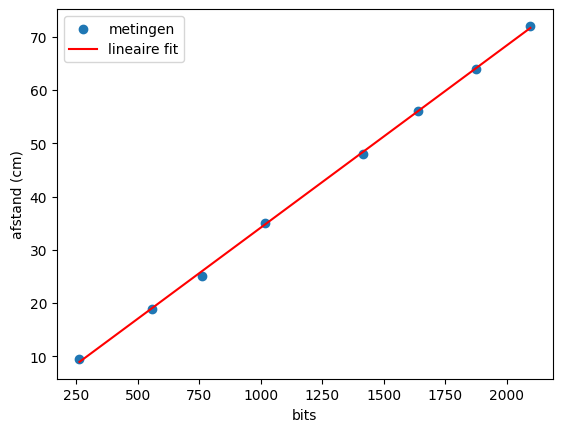

In [3]:
# verwerk hier jullie kalibratiemetingen

from scipy.optimize import curve_fit


afstand = np.array([9.6, 18.9, 25.1, 35.1, 48.0, 56.1, 64.0, 72])  # cm
bits = np.array([263, 556, 760, 1017, 1417, 1640, 1875, 2096])

# scatter plot
plt.scatter(bits, afstand, label="metingen")

# lineaire fitfunctie
def fitfunc(x, a, b):
    return a*x + b

# curve fit
popt, pcov = curve_fit(fitfunc, bits, afstand)
a, b = popt

print("a =", a)
print("b =", b)

# maak mooie lijn
bits_fit = np.linspace(min(bits), max(bits), 100)
afstand_fit = fitfunc(bits_fit, a, b)

# plot fit
plt.plot(bits_fit, afstand_fit, label="lineaire fit", color="red")

plt.xlabel("bits")
plt.ylabel("afstand (cm)")
plt.legend()
plt.show()

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  42.74
1   0  30   0  20  42.77
2  40   0  30   0  44.07
3  30   0  20   0  41.75


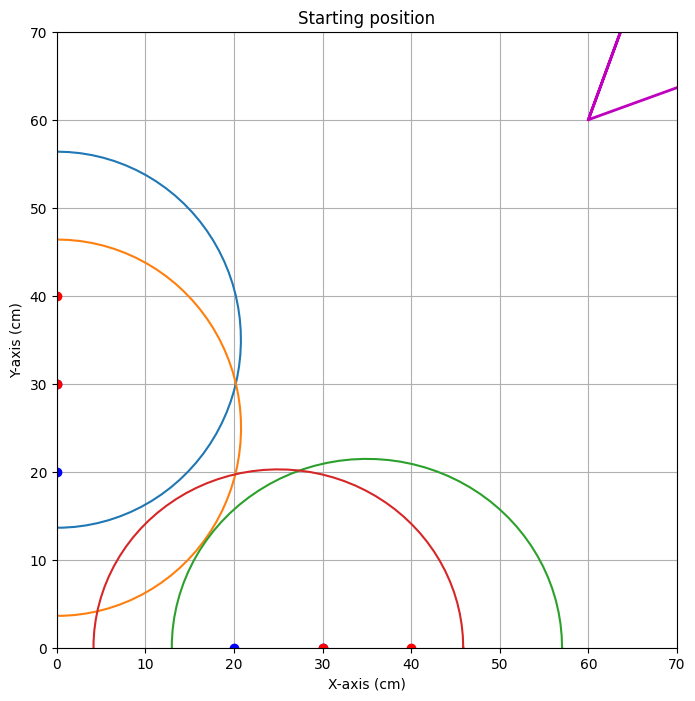


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.122


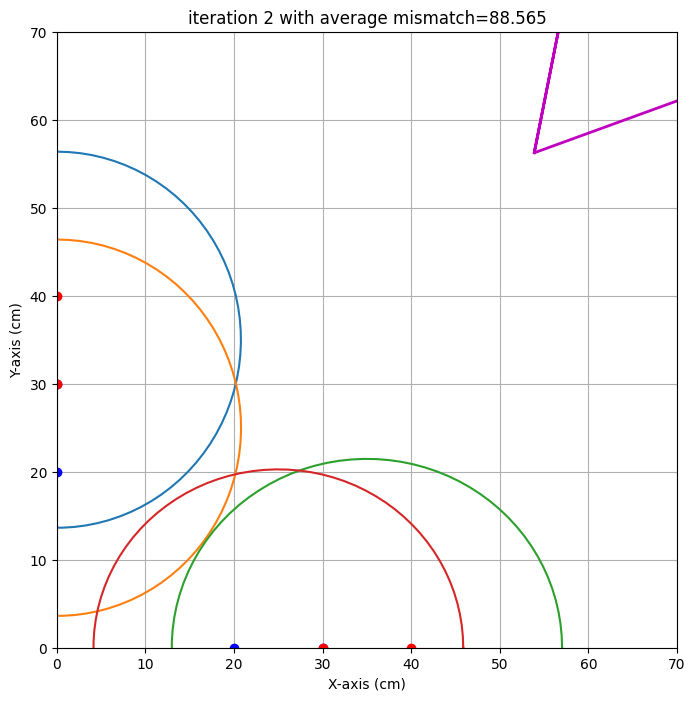

end iteration 2 with average mismatch=88.565


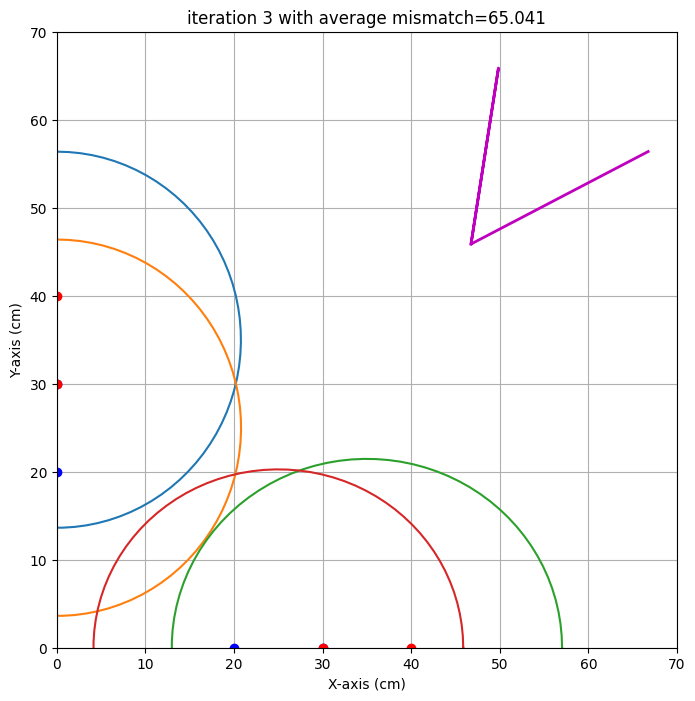

end iteration 3 with average mismatch=65.041


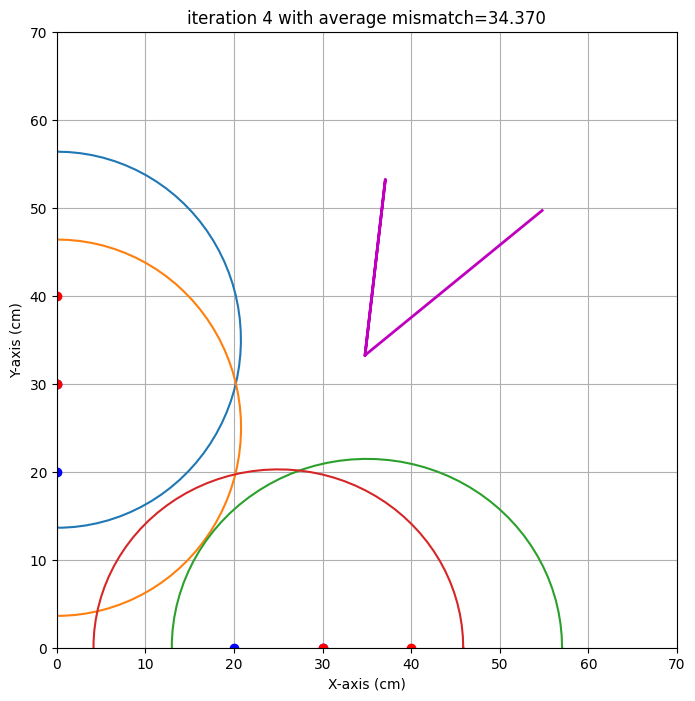

end iteration 4 with average mismatch=34.370


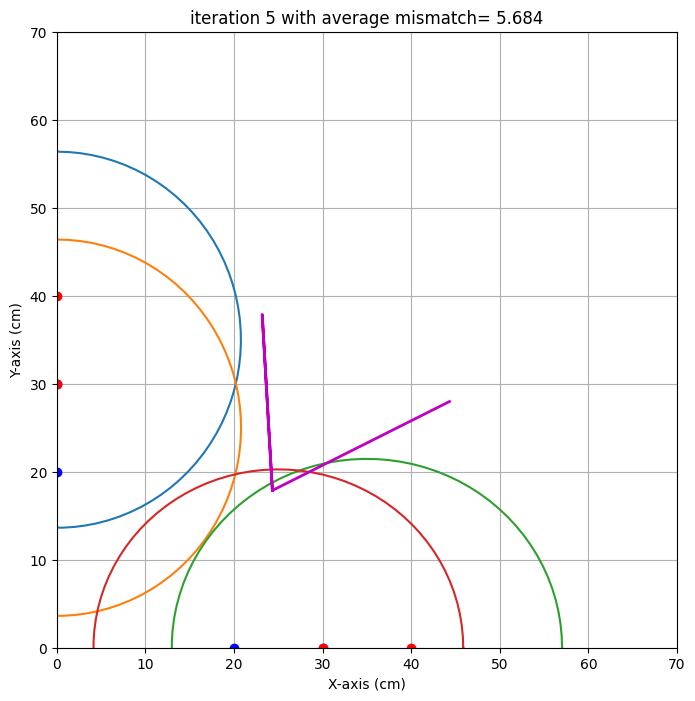

end iteration 5 with average mismatch= 5.684


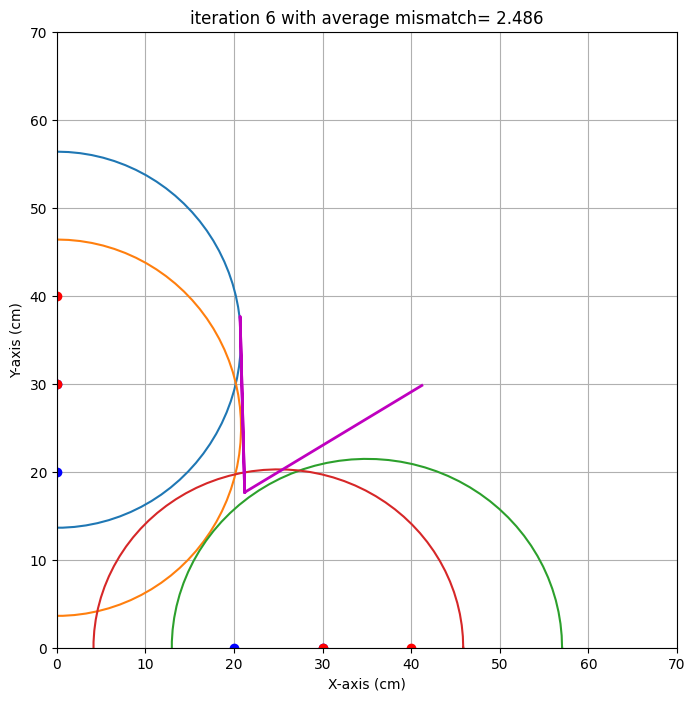

end iteration 6 with average mismatch= 2.486
end iteration 7 with average mismatch= 2.386


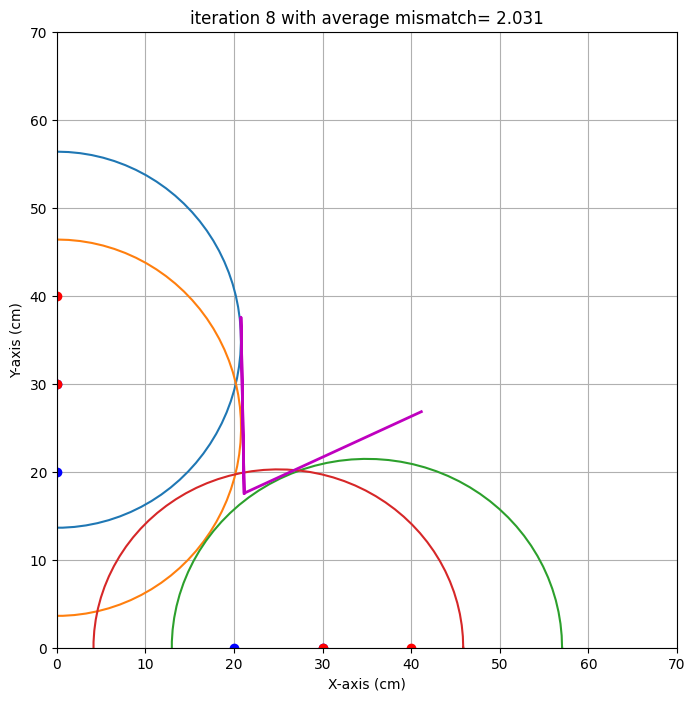

end iteration 8 with average mismatch= 2.031
end iteration 9 with average mismatch= 2.031


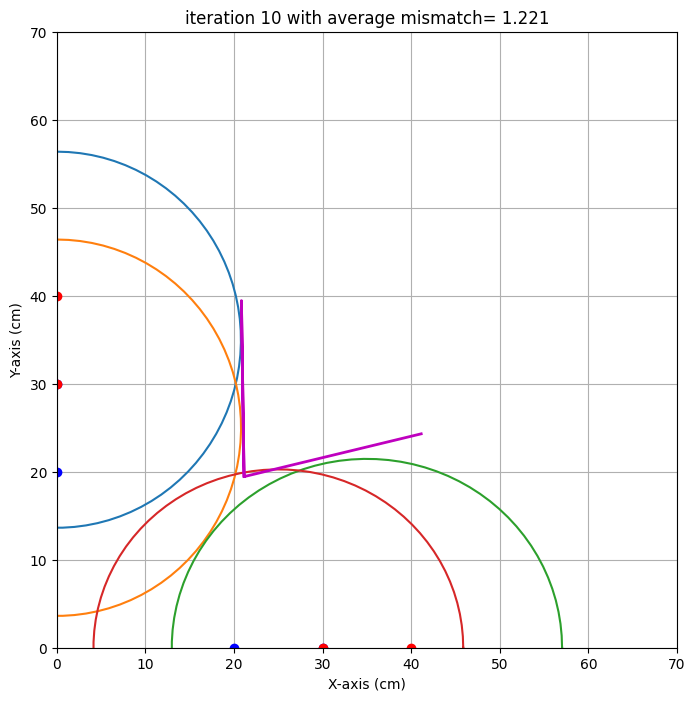

end iteration 10 with average mismatch= 1.221


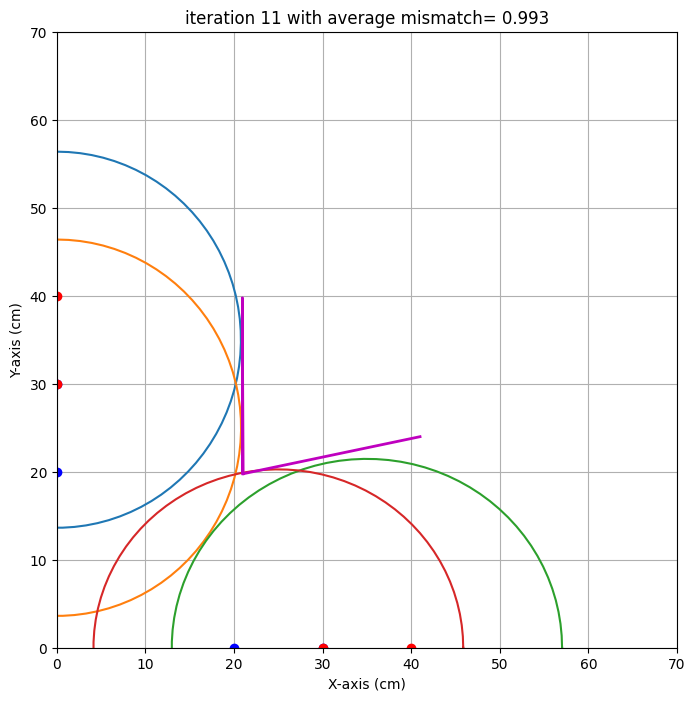

end iteration 11 with average mismatch= 0.993


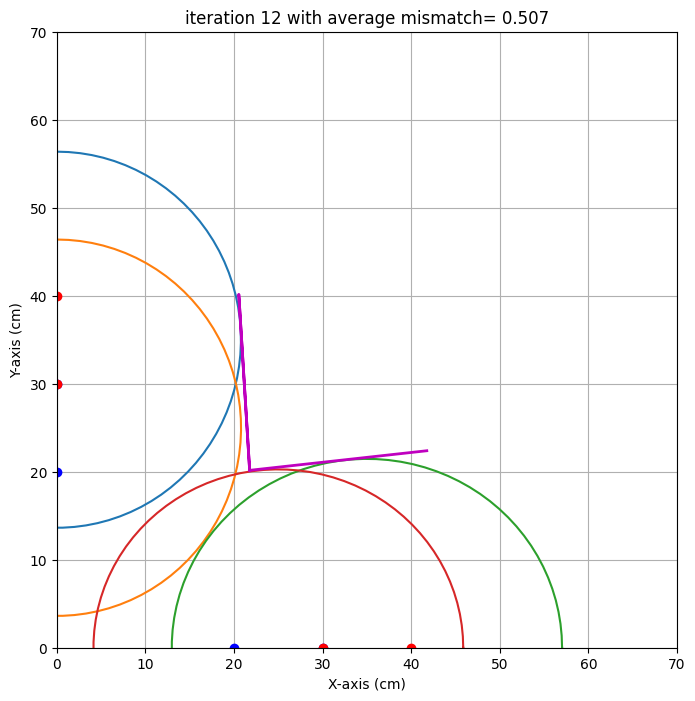

end iteration 12 with average mismatch= 0.507
end iteration 13 with average mismatch= 0.506
end iteration 14 with average mismatch= 0.503


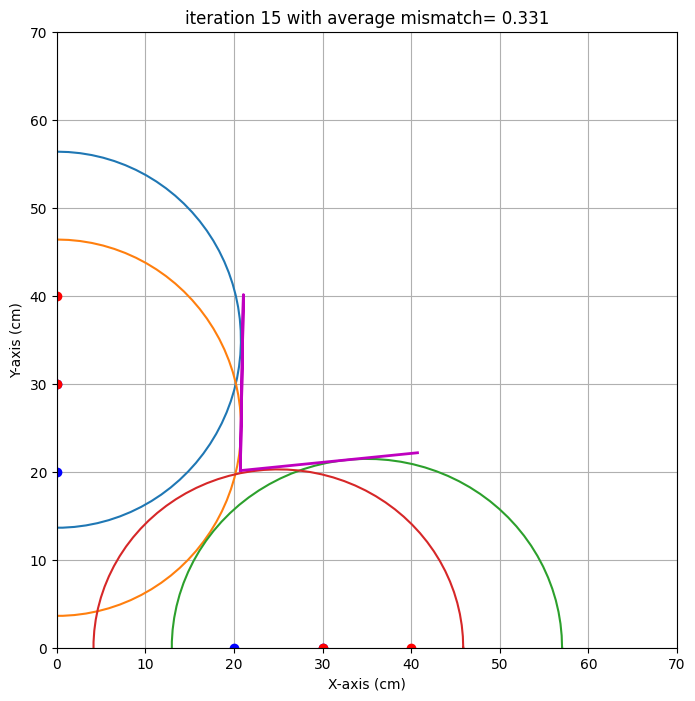

end iteration 15 with average mismatch= 0.331
end iteration 16 with average mismatch= 0.328
end iteration 17 with average mismatch= 0.300


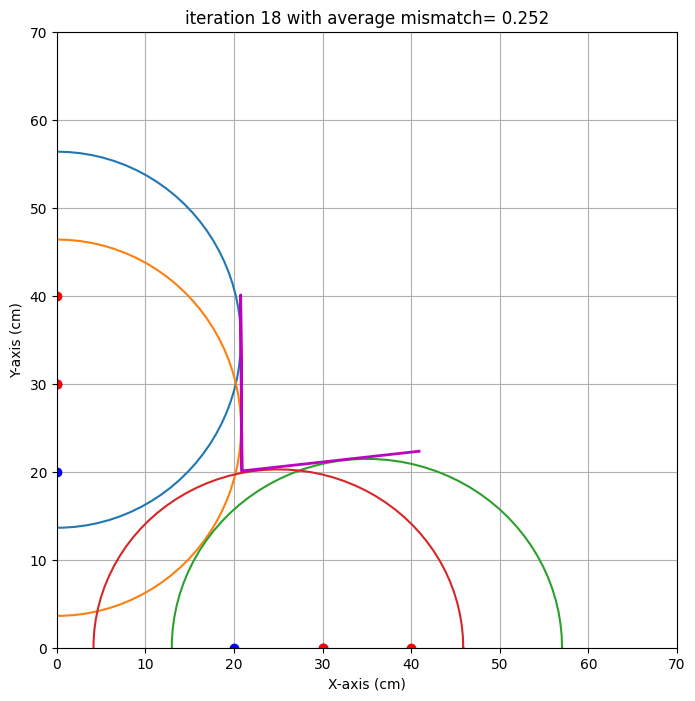

end iteration 18 with average mismatch= 0.252


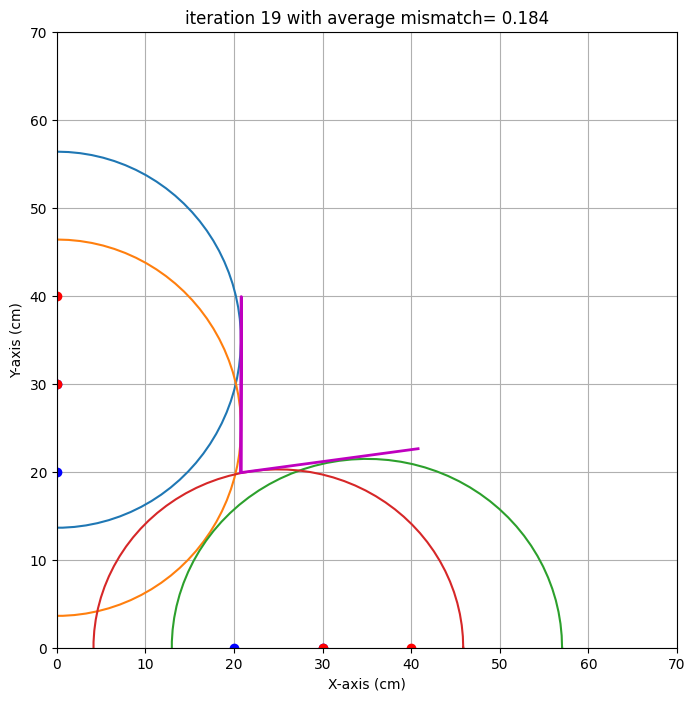

end iteration 19 with average mismatch= 0.184
end iteration 20 with average mismatch= 0.182
end iteration 21 with average mismatch= 0.182
end iteration 22 with average mismatch= 0.182
end iteration 23 with average mismatch= 0.182
end iteration 24 with average mismatch= 0.182
end iteration 25 with average mismatch= 0.182
end iteration 26 with average mismatch= 0.182
end iteration 27 with average mismatch= 0.182
end iteration 28 with average mismatch= 0.182
end iteration 29 with average mismatch= 0.182
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.182
###############################################################################
end of iteration  30
Best alpha=   7.73 with uncertainty=   2.39
Best beta =   0.10 with uncertainty=   2.27
Best x0   =  20.77 with uncertainty=   0.24
Best y0   =  19.90 with uncertainty=   0.40
#####################################

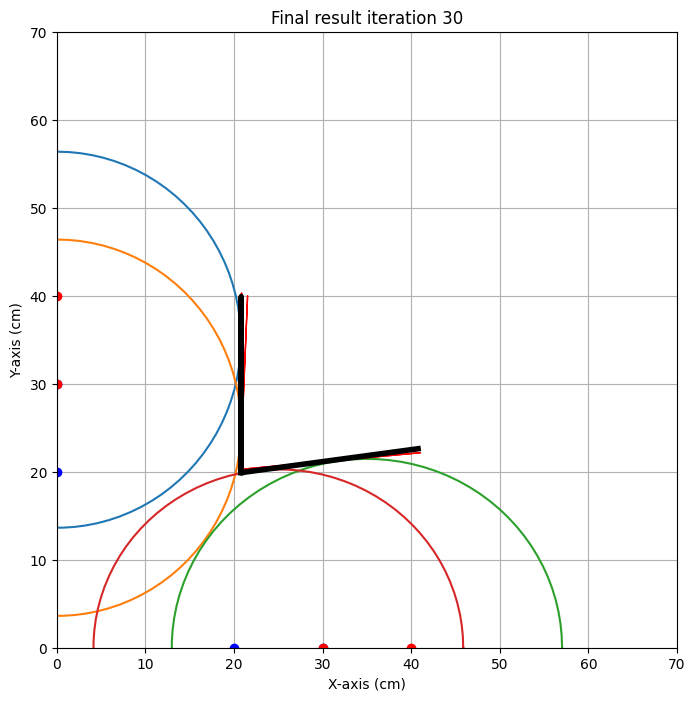

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,42.74],
    [0,30,0,20,42.77],
    # [0,10,0,20,],      #geenmeting
    [40,0,30,0,44.07],
    [30,0,20,0,41.75],
    # [10,0,20,0,],      #geenmeting  
    # [10,0,0,10,]       #geenmeting
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 20.8 cm met een standaardafwijking van 0.2 cm 
y0: 19.9 cm met een standaardafwijking van 0.4 cm 
alpha: 7.7 graden met een standaardafwijking van 2.4 graad 
beta: 0.1 graden met een standaardafwijking van 2.3 graad 



## Opdracht 5: Iteratie 0

#### algoritme julia
Voeg een foto in van het algoritme van het eerste groepslid
<img src="IMG_8653.jpeg" width="400">

#### algoritme daniel
Voeg een foto in van het algoritme van het tweede groepslid
<img src="IMG_8654.jpeg" width="400">

#### algoritme tobias
Voeg een foto in van het algoritme van het derde groepslid
<img src="IMG_8655.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':15,  
           'y0':25,
           'alpha' : -8,
           'beta' : 0,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Tobias' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                              #   [0,15,0,5,np.nan],
                              #   [0,25,0,15,np.nan],
                                [0,35,0,25,32.35],
                                [0,40,0,30,33.6],
                                [0,45,0,35,33.1],
                                [0,50,0,40,32.79],
                                [0,55,0,45,37.2],
                                [15,0,5,0,55.02],
                                [20,0,10,0,50.36],
                                [25,0,15,0,49.2],
                                [30,0,20,0,48.7],
                                [35,0,25,0,47.66],
                                [40,0,30,0,46.57],
                                # [45,0,35,0,np.nan],
    
    ]),
       'Daniel' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[ 
           [10,0,20,0,51.25],
           [20,0,30,0,48.62],
           [30,0,40,0,46.06],
          #  [40,0,30,0,np.nan],
          #  [0,10,0,20,np.nan],
           [0,20,0,30,34.2],
           [0,30,0,40,34.23],
           [0,40,0,50,33.34]
          #  [0,50,0,60,np.nan],

    #zelf aanvullen
    ]),   
      'Julia' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
     [10,0,20,0,51.25],
           [20,0,30,0,48.62],
           [30,0,40,0,46.06],
          #  [40,0,30,0,np.nan],
          #  [0,10,0,20,np.nan],
           [0,20,0,30,34.2],
           [0,30,0,40,34.23],
           [0,40,0,50,33.34]
          #  [0,50,0,60,np.nan],
    ]),
      
      }


## Opdracht 7: Evaluatie.

Tobias
Running the imaging algorithm with the following data:
    xs  ys  xr  yr      R
0    0  35   0  25  32.35
1    0  40   0  30  33.60
2    0  45   0  35  33.10
3    0  50   0  40  32.79
4    0  55   0  45  37.20
5   15   0   5   0  55.02
6   20   0  10   0  50.36
7   25   0  15   0  49.20
8   30   0  20   0  48.70
9   35   0  25   0  47.66
10  40   0  30   0  46.57


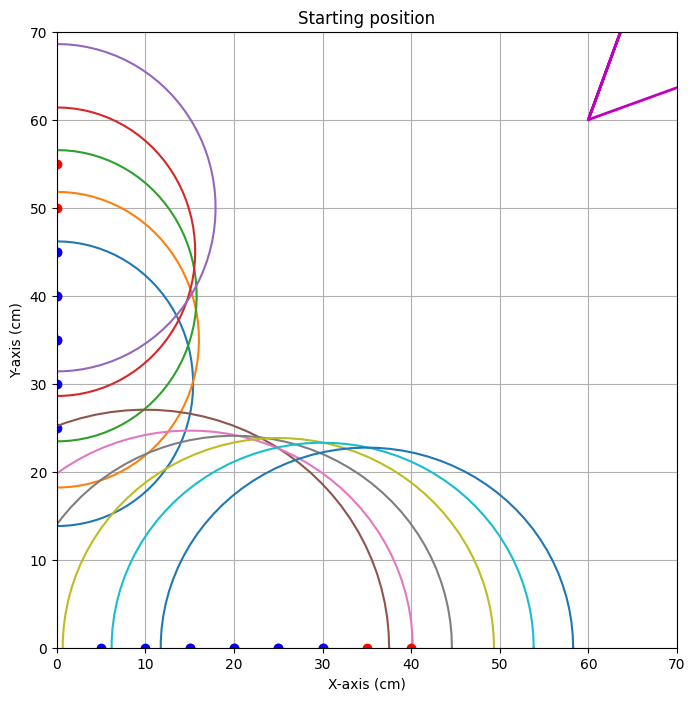


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.964


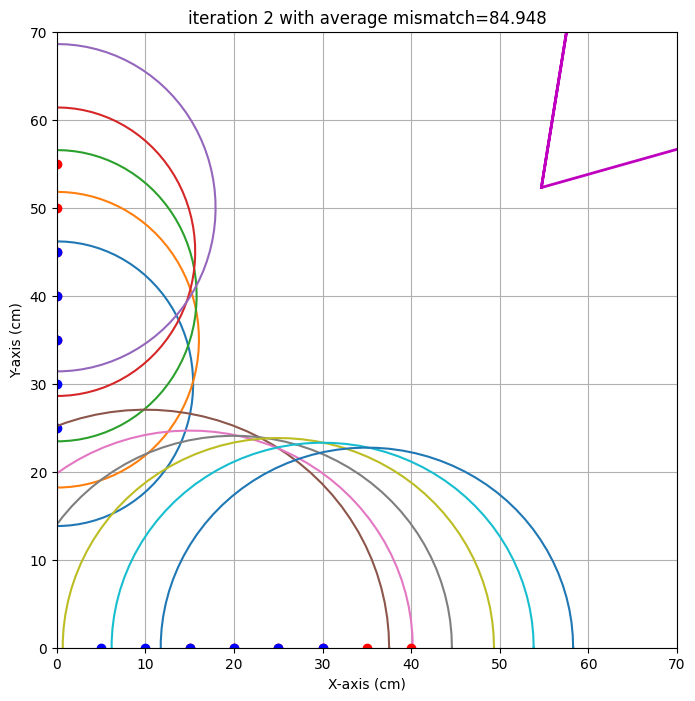

end iteration 2 with average mismatch=84.948


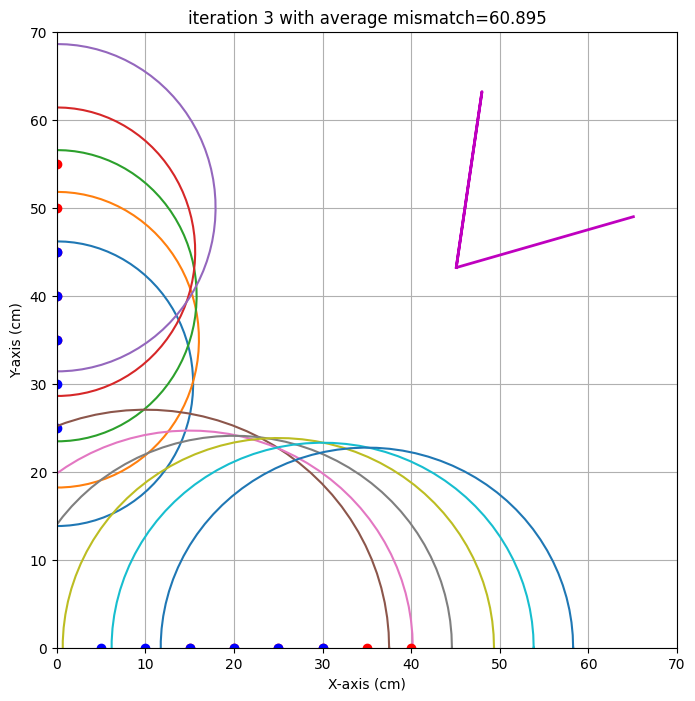

end iteration 3 with average mismatch=60.895


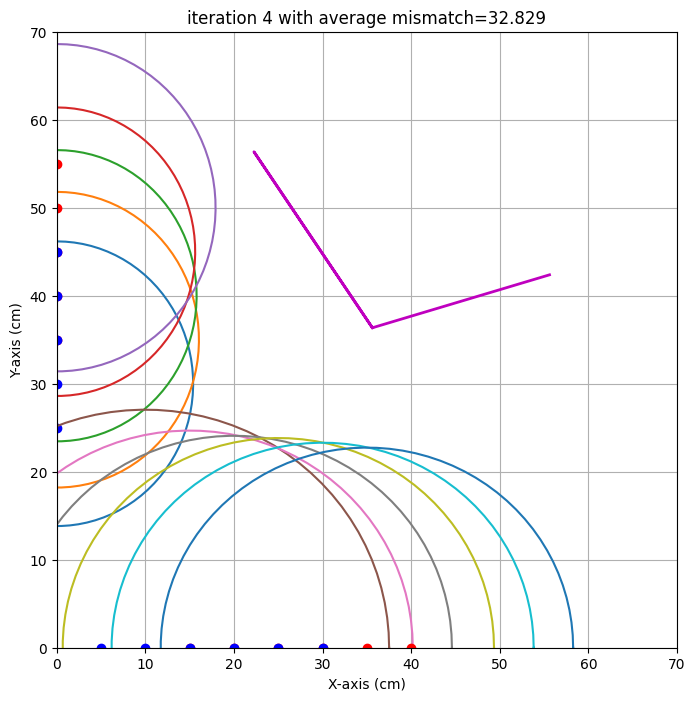

end iteration 4 with average mismatch=32.829


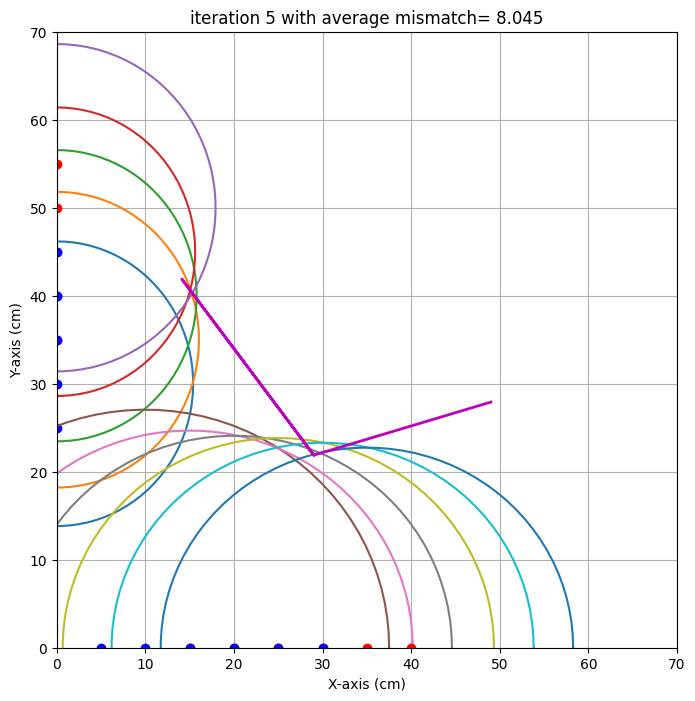

end iteration 5 with average mismatch= 8.045


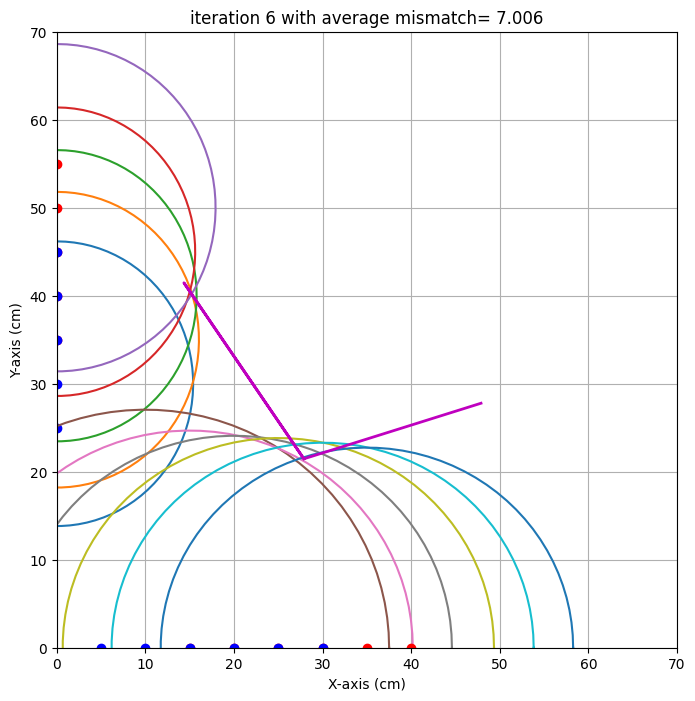

end iteration 6 with average mismatch= 7.006
end iteration 7 with average mismatch= 6.835
end iteration 8 with average mismatch= 6.590


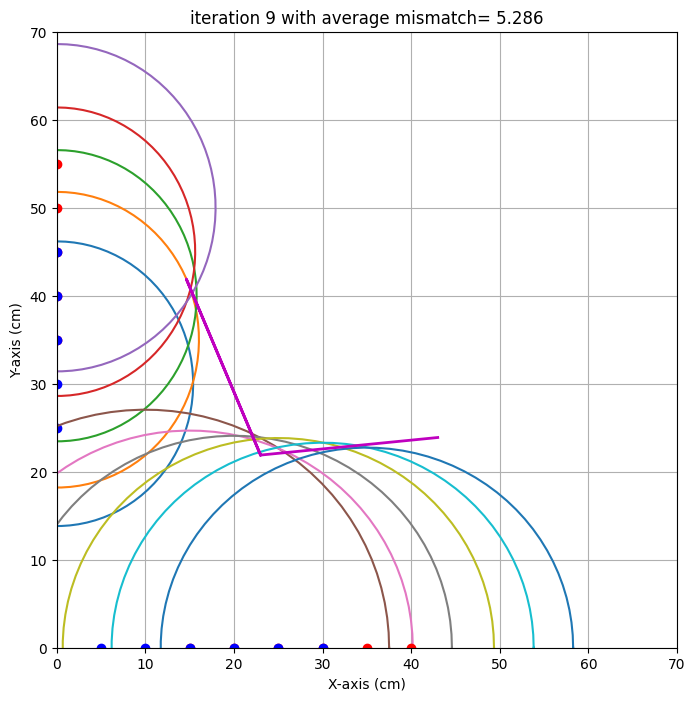

end iteration 9 with average mismatch= 5.286


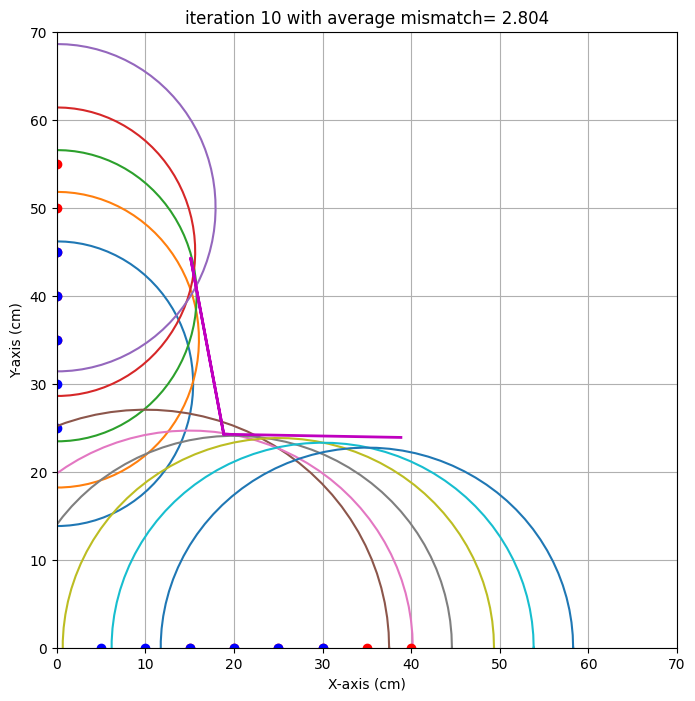

end iteration 10 with average mismatch= 2.804


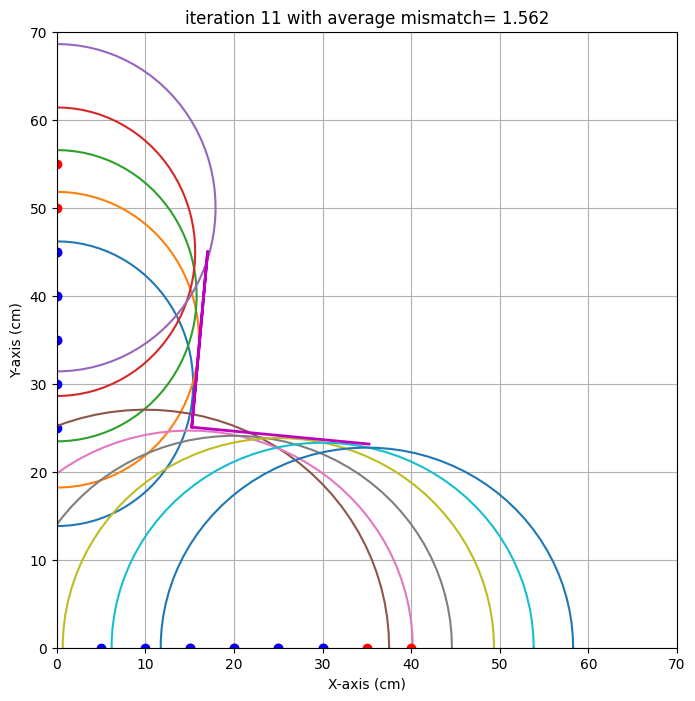

end iteration 11 with average mismatch= 1.562
end iteration 12 with average mismatch= 1.545
end iteration 13 with average mismatch= 1.432
end iteration 14 with average mismatch= 1.394
end iteration 15 with average mismatch= 1.387
end iteration 16 with average mismatch= 1.386
end iteration 17 with average mismatch= 1.386
end iteration 18 with average mismatch= 1.386
end iteration 19 with average mismatch= 1.386
end iteration 20 with average mismatch= 1.386
end iteration 21 with average mismatch= 1.386
end iteration 22 with average mismatch= 1.386
end iteration 23 with average mismatch= 1.386
end iteration 24 with average mismatch= 1.386
end iteration 25 with average mismatch= 1.386
end iteration 26 with average mismatch= 1.386
end iteration 27 with average mismatch= 1.354
end iteration 28 with average mismatch= 1.341
end iteration 29 with average mismatch= 1.337
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

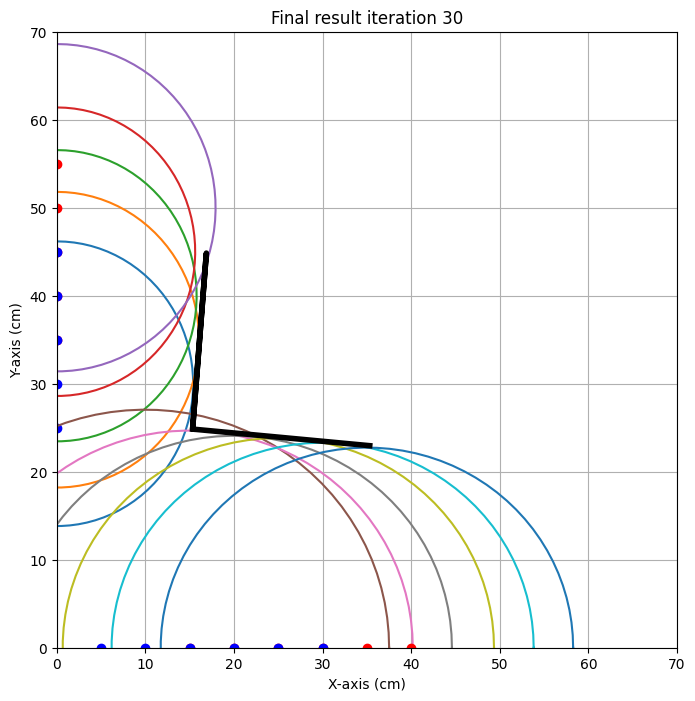

{'alpha': np.float64(-5.3833472566980385), 'alpha_eps': np.float64(0.3550971716198825), 'beta': np.float64(4.44694511325269), 'beta_eps': np.float64(0.3657174962604284), 'x0': np.float64(15.318516406502429), 'x0_eps': np.float64(0.13011171750569517), 'y0': np.float64(24.843904281994774), 'y0_eps': np.float64(0.10243517357204013)}
Daniel
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  10   0  20   0  51.25
1  20   0  30   0  48.62
2  30   0  40   0  46.06
3   0  20   0  30  34.20
4   0  30   0  40  34.23
5   0  40   0  50  33.34


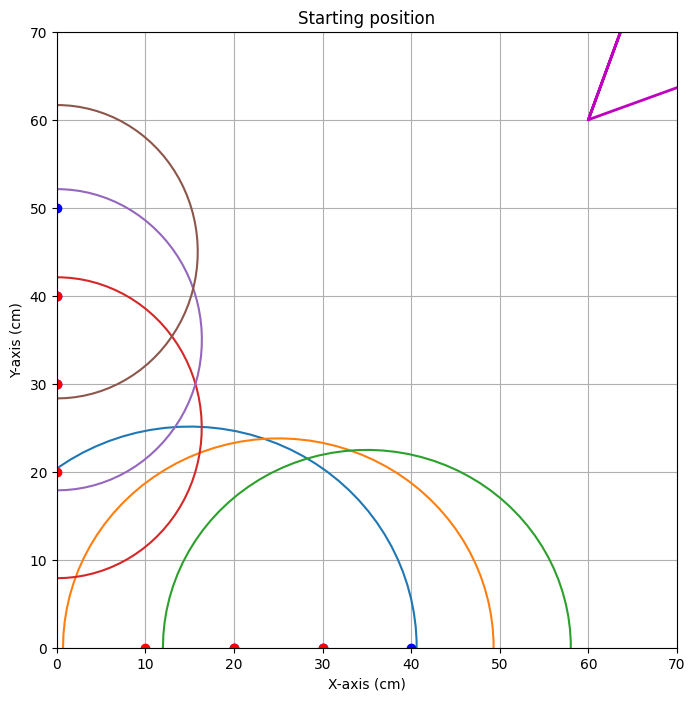


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.080


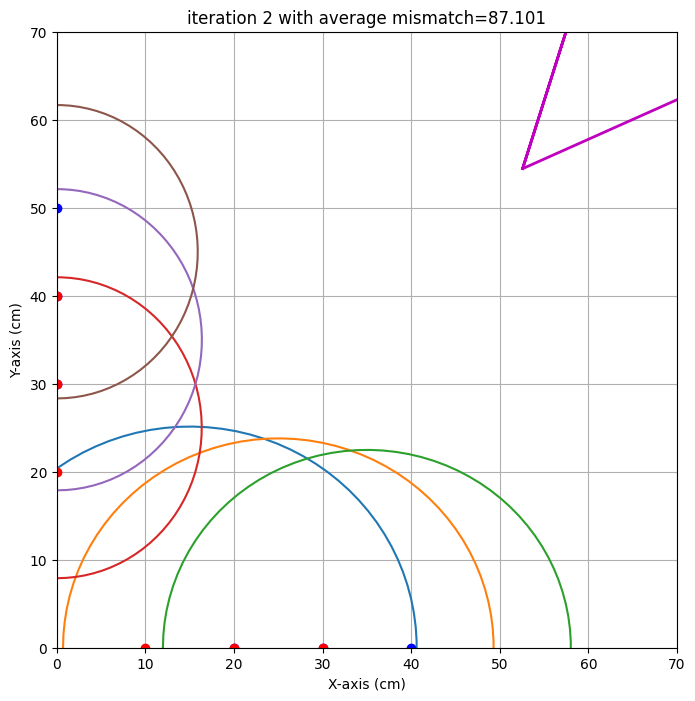

end iteration 2 with average mismatch=87.101


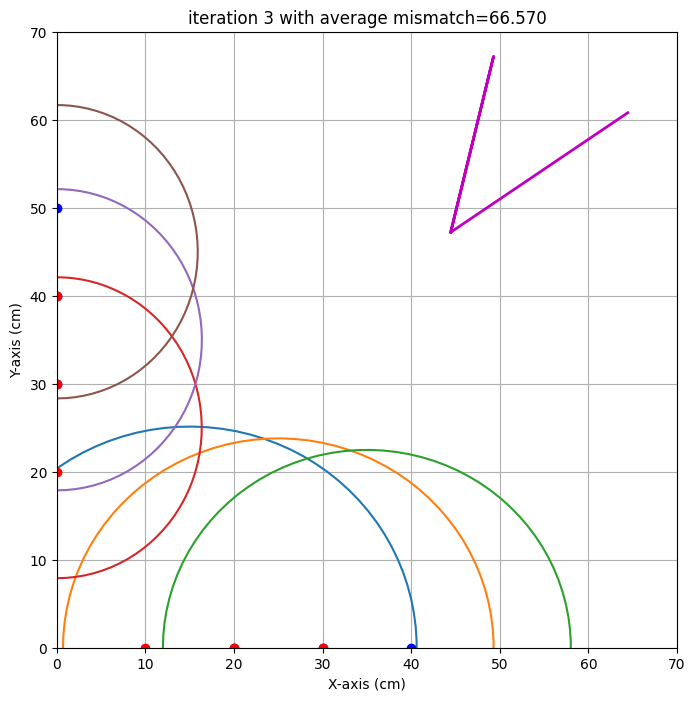

end iteration 3 with average mismatch=66.570


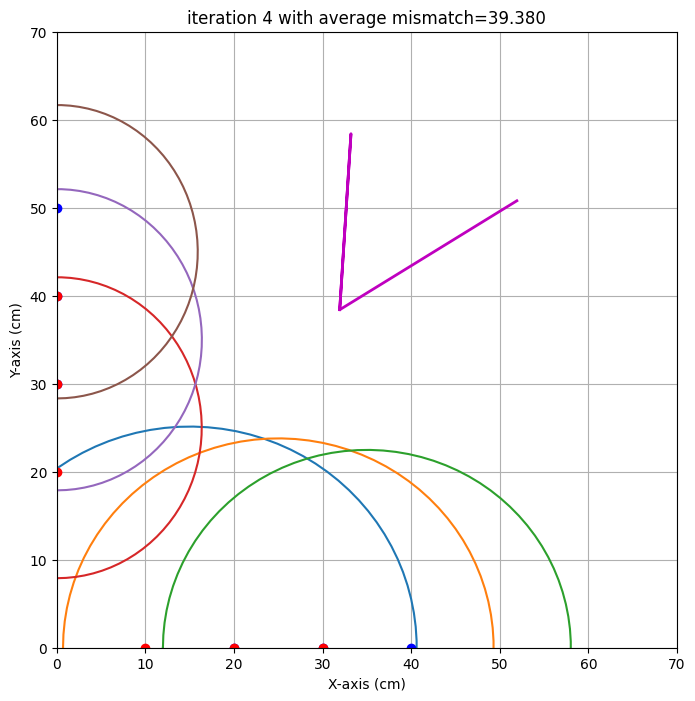

end iteration 4 with average mismatch=39.380


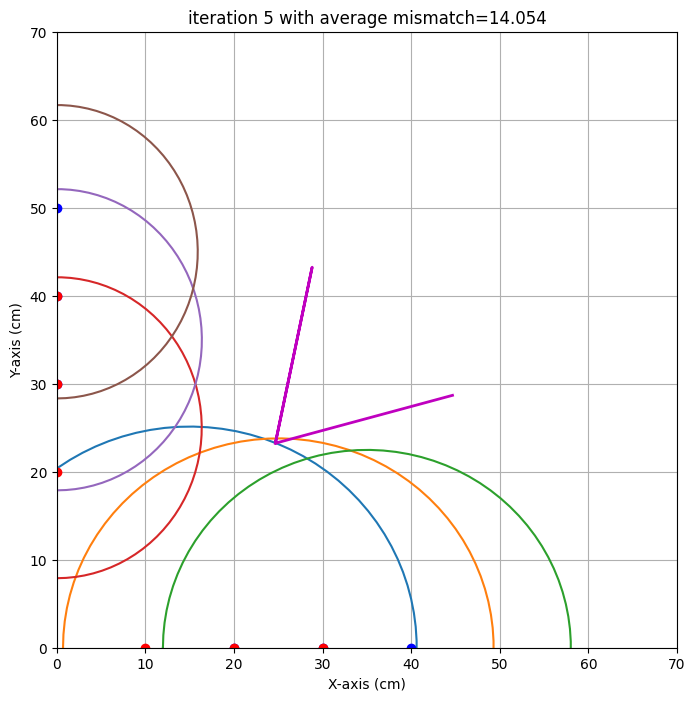

end iteration 5 with average mismatch=14.054


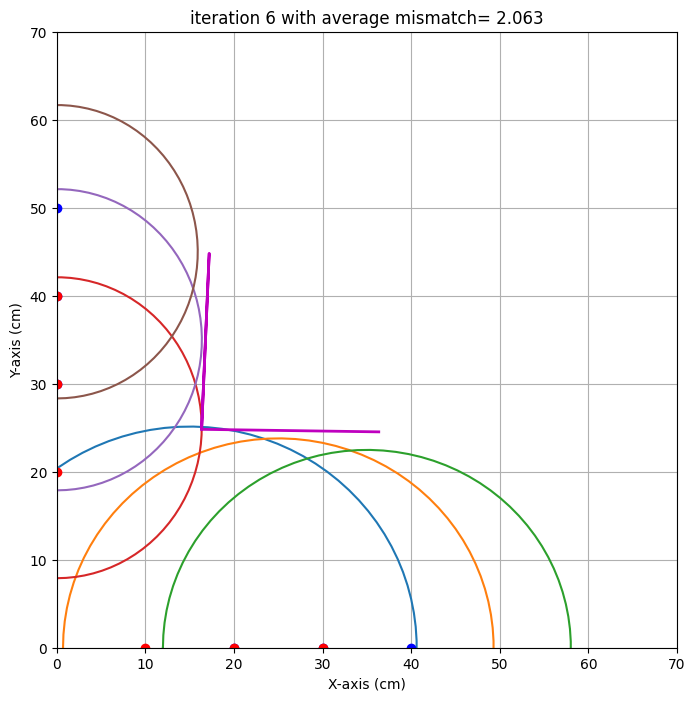

end iteration 6 with average mismatch= 2.063


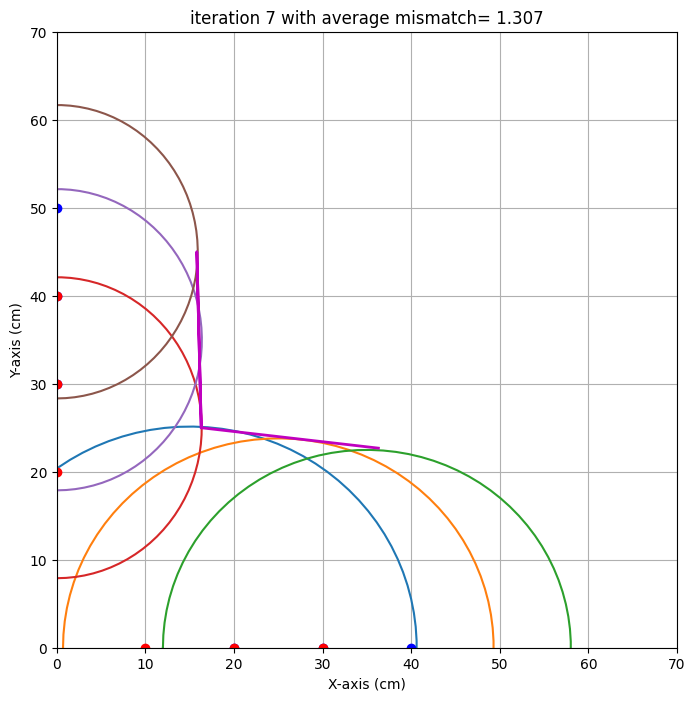

end iteration 7 with average mismatch= 1.307


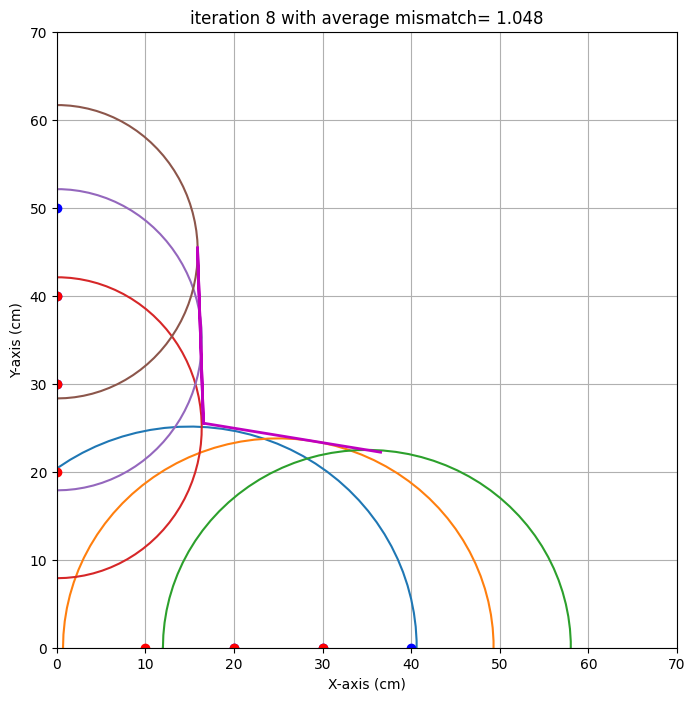

end iteration 8 with average mismatch= 1.048
end iteration 9 with average mismatch= 1.046
end iteration 10 with average mismatch= 0.983
end iteration 11 with average mismatch= 0.926
end iteration 12 with average mismatch= 0.919
end iteration 13 with average mismatch= 0.912
end iteration 14 with average mismatch= 0.912
end iteration 15 with average mismatch= 0.911
end iteration 16 with average mismatch= 0.911
end iteration 17 with average mismatch= 0.911
end iteration 18 with average mismatch= 0.845
end iteration 19 with average mismatch= 0.842
end iteration 20 with average mismatch= 0.841
end iteration 21 with average mismatch= 0.840
end iteration 22 with average mismatch= 0.840
end iteration 23 with average mismatch= 0.840
end iteration 24 with average mismatch= 0.840
end iteration 25 with average mismatch= 0.840
end iteration 26 with average mismatch= 0.840
end iteration 27 with average mismatch= 0.840
end iteration 28 with average mismatch= 0.840
end iteration 29 with average mismat

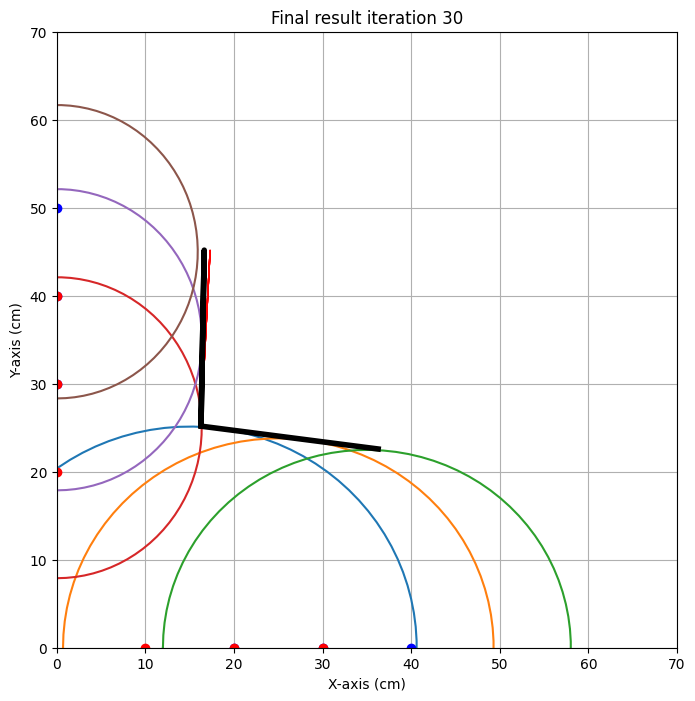

{'alpha': np.float64(-7.391399425754672), 'alpha_eps': np.float64(0.3006375255778462), 'beta': np.float64(1.0488929842818397), 'beta_eps': np.float64(1.9300131225661177), 'x0': np.float64(16.268283924543113), 'x0_eps': np.float64(0.01147343140010193), 'y0': np.float64(25.178618692197535), 'y0_eps': np.float64(0.02774960793613701)}
Julia
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  10   0  20   0  51.25
1  20   0  30   0  48.62
2  30   0  40   0  46.06
3   0  20   0  30  34.20
4   0  30   0  40  34.23
5   0  40   0  50  33.34


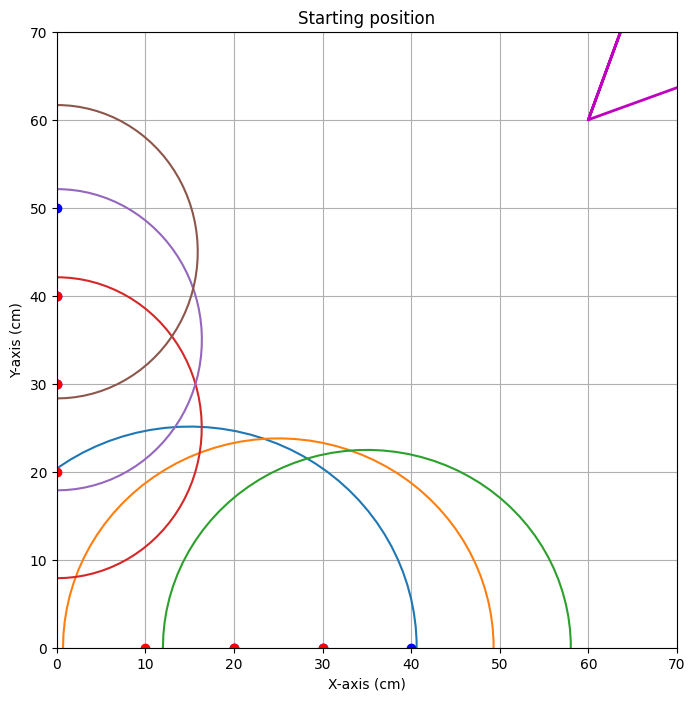


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.080


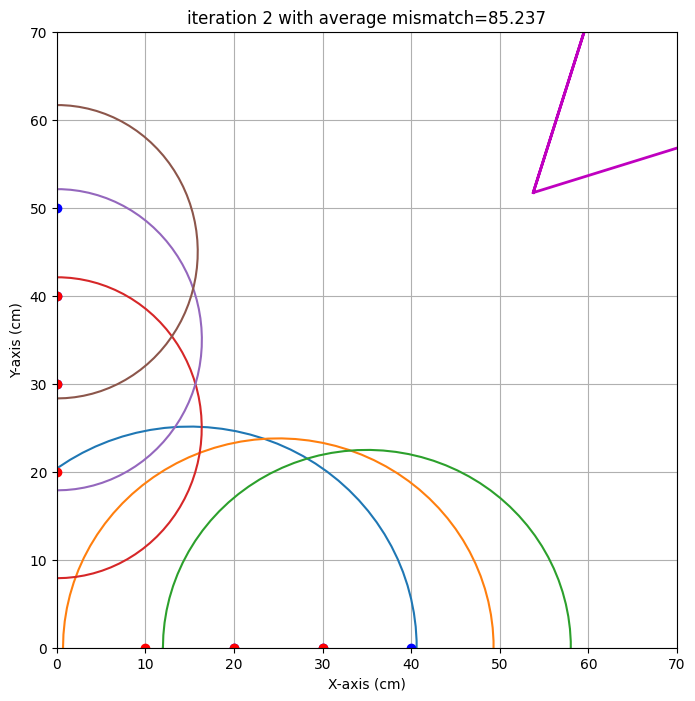

end iteration 2 with average mismatch=85.237


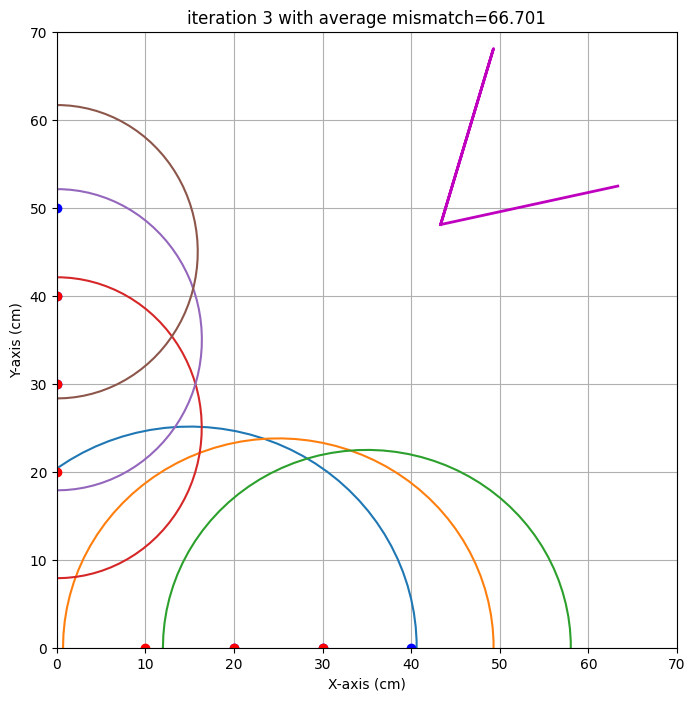

end iteration 3 with average mismatch=66.701


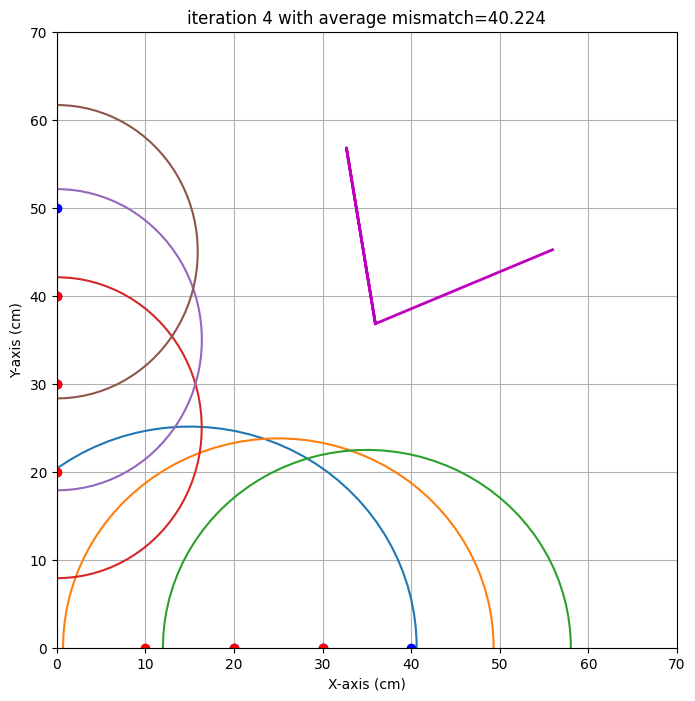

end iteration 4 with average mismatch=40.224


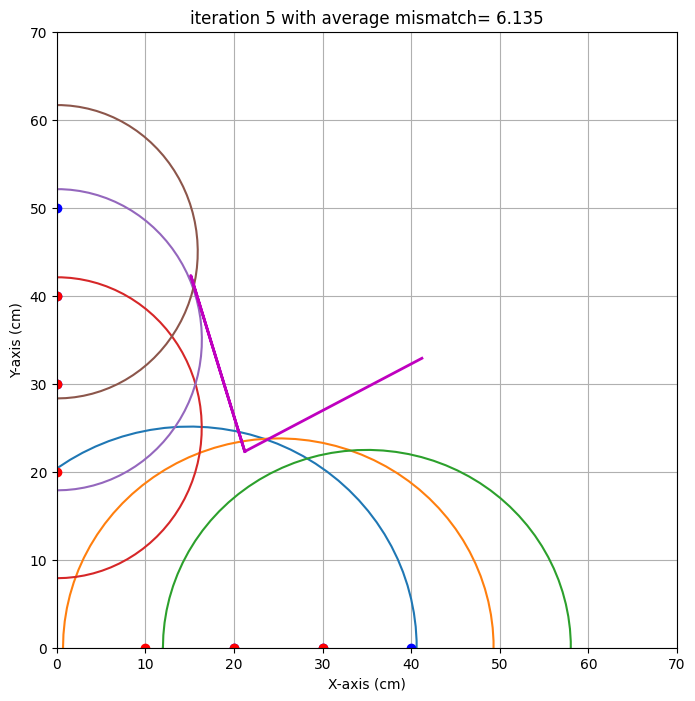

end iteration 5 with average mismatch= 6.135


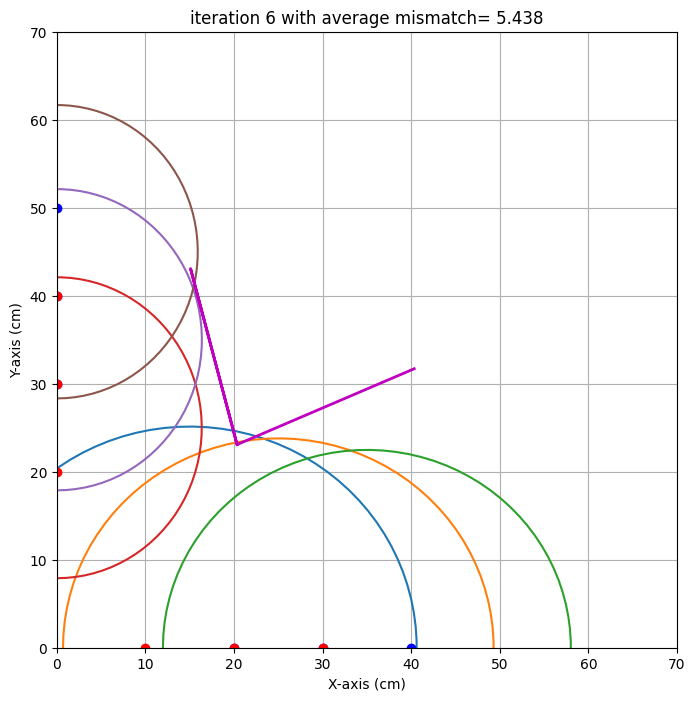

end iteration 6 with average mismatch= 5.438


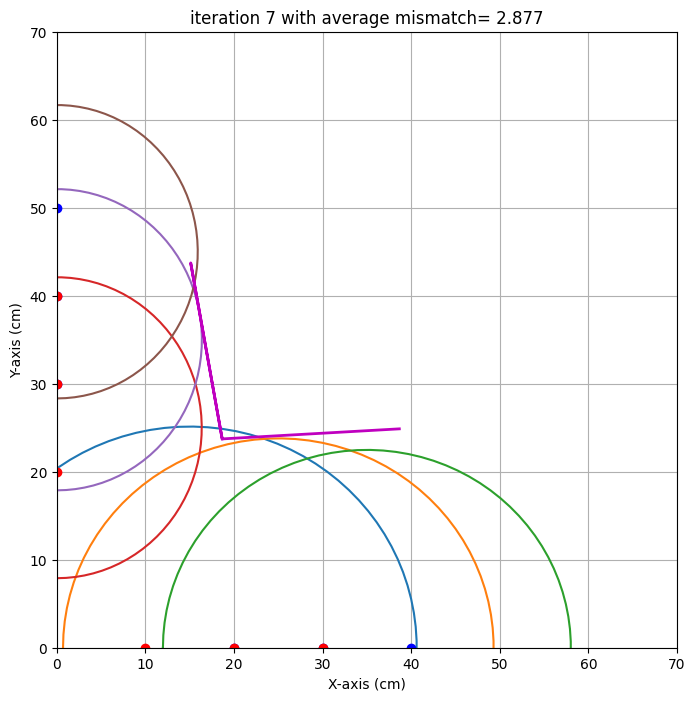

end iteration 7 with average mismatch= 2.877


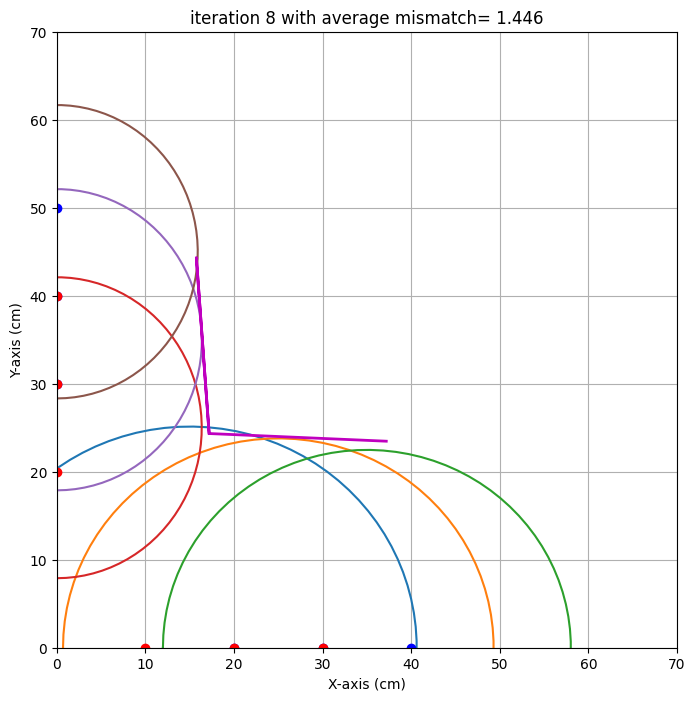

end iteration 8 with average mismatch= 1.446


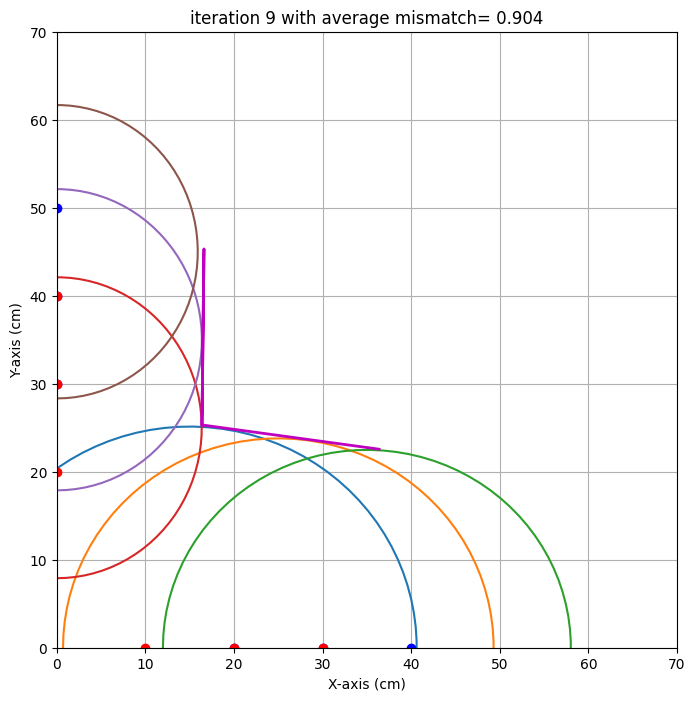

end iteration 9 with average mismatch= 0.904
end iteration 10 with average mismatch= 0.872
end iteration 11 with average mismatch= 0.870
end iteration 12 with average mismatch= 0.870
end iteration 13 with average mismatch= 0.870
end iteration 14 with average mismatch= 0.870
end iteration 15 with average mismatch= 0.867
end iteration 16 with average mismatch= 0.864
end iteration 17 with average mismatch= 0.851
end iteration 18 with average mismatch= 0.845
end iteration 19 with average mismatch= 0.844
end iteration 20 with average mismatch= 0.842
end iteration 21 with average mismatch= 0.842
end iteration 22 with average mismatch= 0.842
end iteration 23 with average mismatch= 0.842
end iteration 24 with average mismatch= 0.842
end iteration 25 with average mismatch= 0.842
end iteration 26 with average mismatch= 0.842
end iteration 27 with average mismatch= 0.842
end iteration 28 with average mismatch= 0.842
end iteration 29 with average mismatch= 0.842
Last iteration, also determine unce

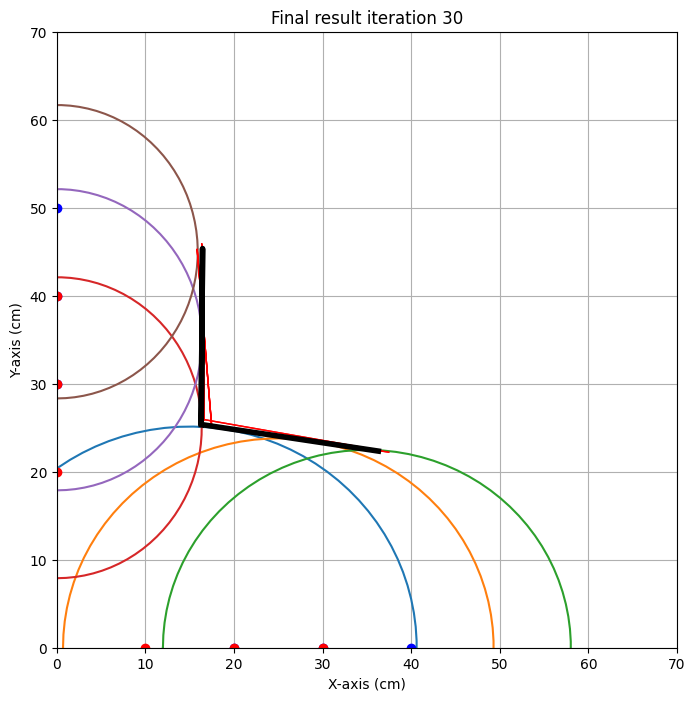

{'alpha': np.float64(-8.586182376310122), 'alpha_eps': np.float64(1.422027303772115), 'beta': np.float64(0.43281775280950924), 'beta_eps': np.float64(5.09277917260338), 'x0': np.float64(16.29286657459114), 'x0_eps': np.float64(1.172222546664674), 'y0': np.float64(25.364329973235726), 'y0_eps': np.float64(0.5565306480942844)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])



In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Tobias 
x0 target is : 15.0. Gevonden waarde: 15.3 cm met een standaardafwijking van 0.1 cm 
y0 target is : 25.0. Gevonden waarde: 24.8 cm met een standaardafwijking van 0.1 cm 
alpha target is : -8.0. Gevonden waarde: -5.4 graden met een standaardafwijking van 0.4 graad 
beta target is : 0.0. Gevonden waarde: 4.4 graden met een standaardafwijking van 0.4 graad 

Daniel 
x0 target is : 15.0. Gevonden waarde: 16.3 cm met een standaardafwijking van 0.0 cm 
y0 target is : 25.0. Gevonden waarde: 25.2 cm met een standaardafwijking van 0.0 cm 
alpha target is : -8.0. Gevonden waarde: -7.4 graden met een standaardafwijking van 0.3 graad 
beta target is : 0.0. Gevonden waarde: 1.0 graden met een standaardafwijking van 1.9 graad 

Julia 
x0 target is : 15.0. Gevonden waarde: 16.3 cm met een standaardafwijking van 1.2 cm 
y0 target is : 25.0. Gevonden waarde: 25.4 cm met een standaardafwijking van 0.6 cm 
alpha target is : -8.0. Gevonden waarde: -8.6 graden met een standaardafwijking van 1.4 gra

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](IMG_8655.jpeg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

 ![Alt](PXL_20260318_154128154.jpg)

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0   0  20   0  30   95.11
1   0  15   0  25   96.60
2   0  10   0  20  103.14
3   0  25   0  35   92.65
4   0  30   0  40   95.20
5  50   0  60   0   52.31
6  45   0  55   0   52.40
7  40   0  50   0   52.16
8  55   0  65   0   52.10
9  60   0  70   0   52.00


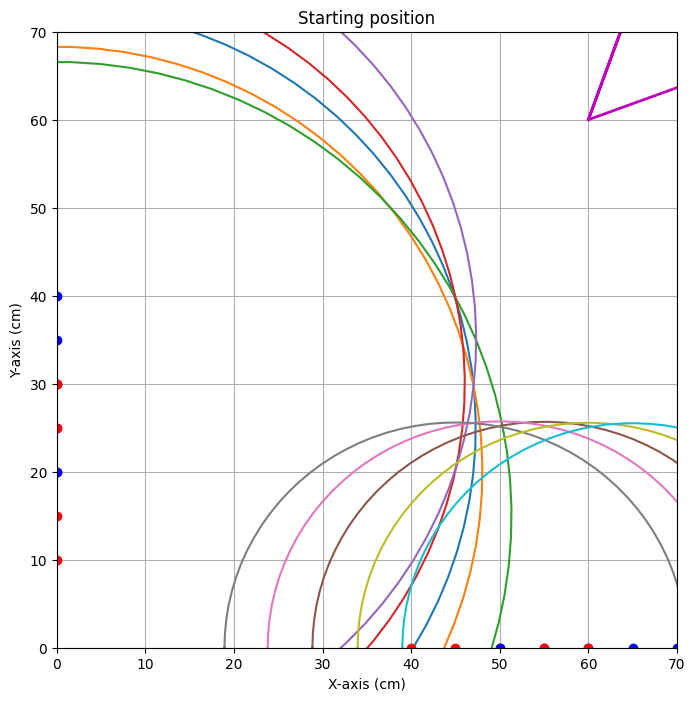


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=63.755


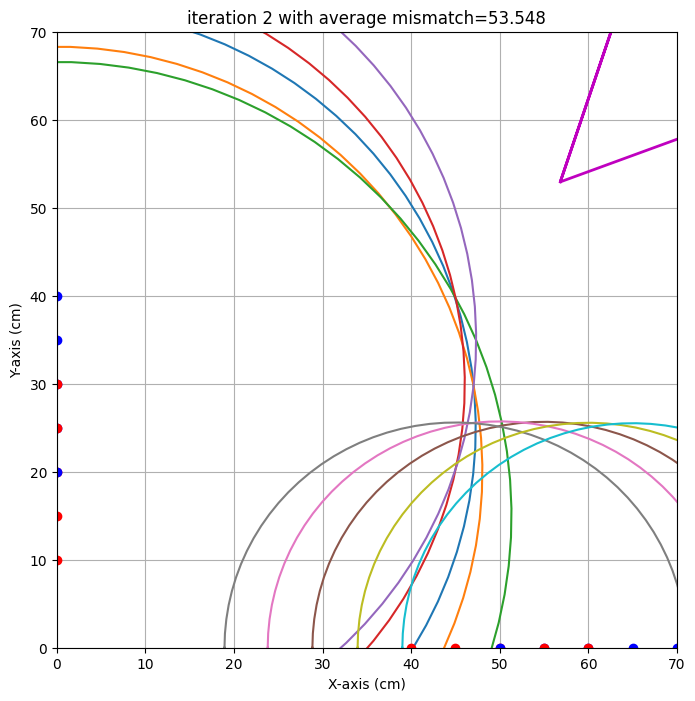

end iteration 2 with average mismatch=53.548


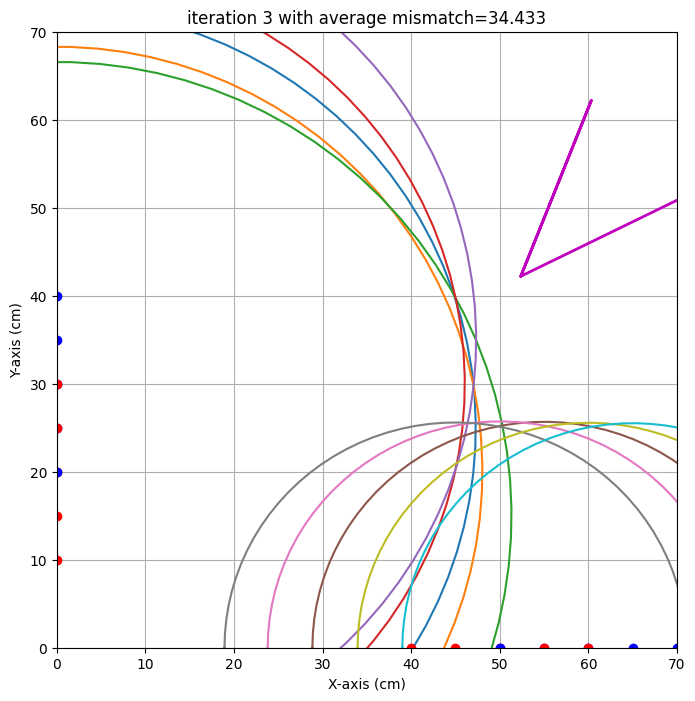

end iteration 3 with average mismatch=34.433


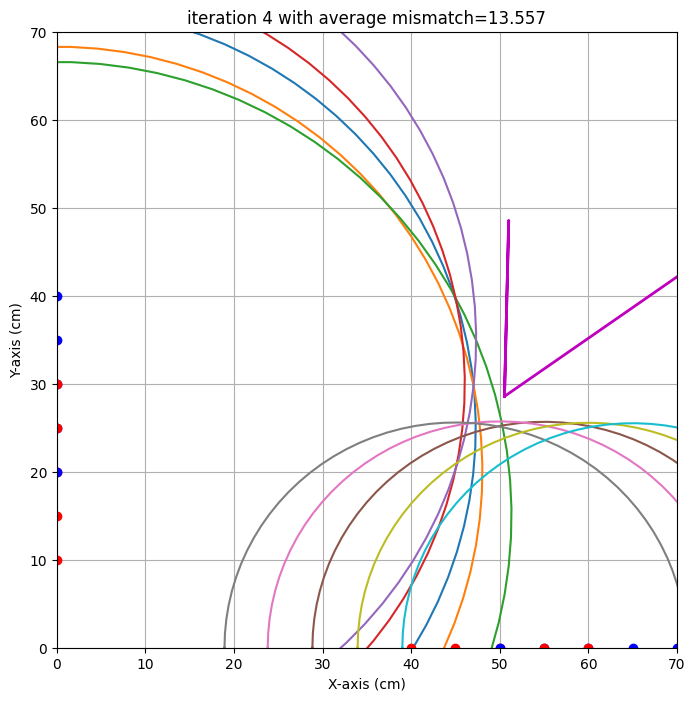

end iteration 4 with average mismatch=13.557


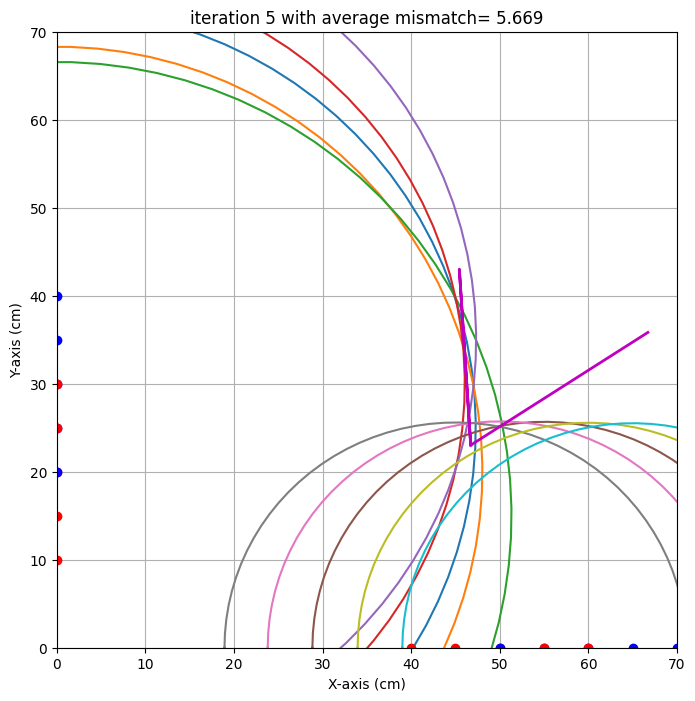

end iteration 5 with average mismatch= 5.669


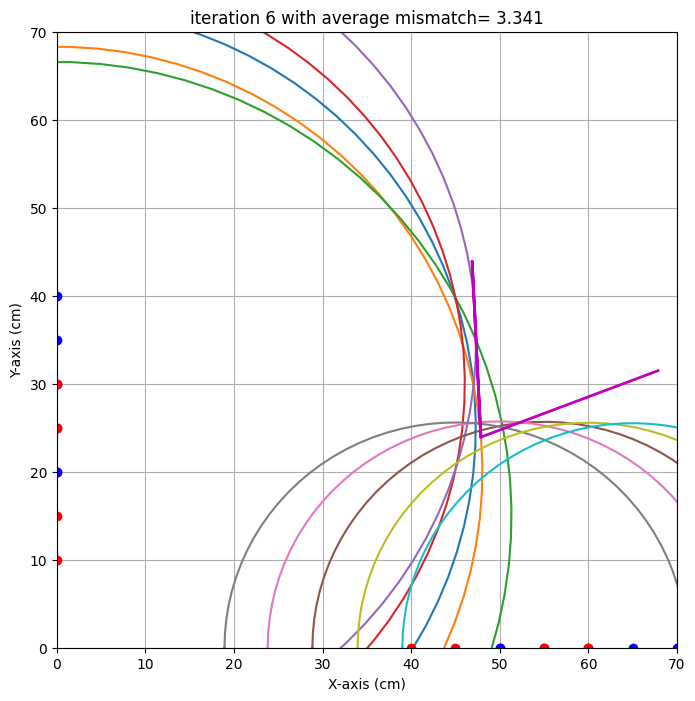

end iteration 6 with average mismatch= 3.341


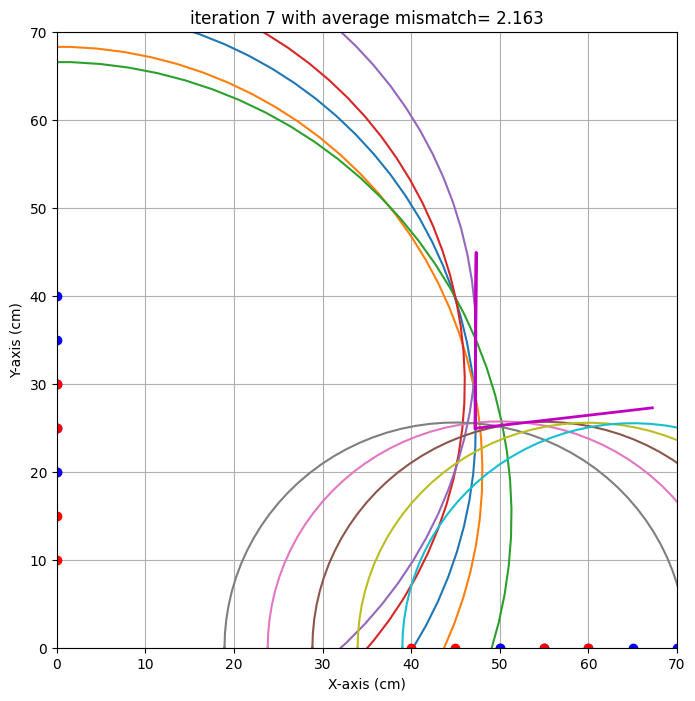

end iteration 7 with average mismatch= 2.163


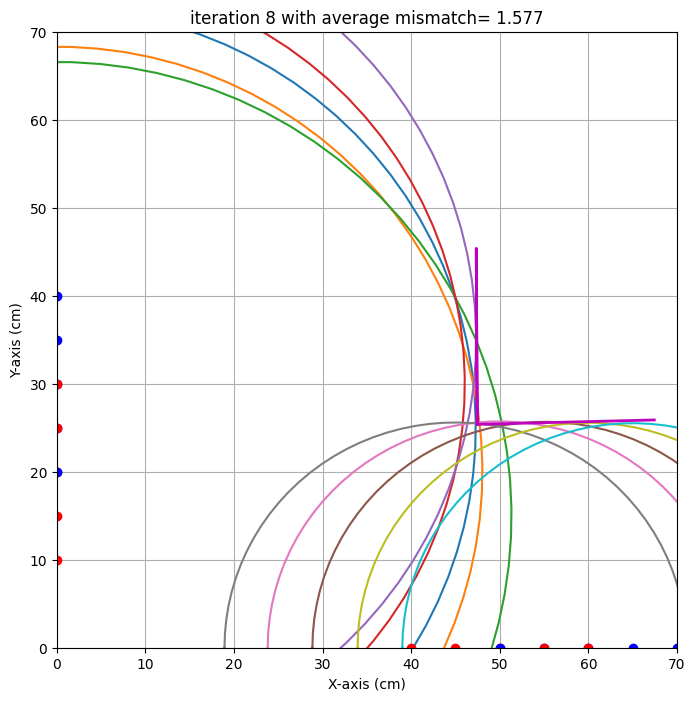

end iteration 8 with average mismatch= 1.577
end iteration 9 with average mismatch= 1.575
end iteration 10 with average mismatch= 1.575
end iteration 11 with average mismatch= 1.575
end iteration 12 with average mismatch= 1.575
end iteration 13 with average mismatch= 1.575
end iteration 14 with average mismatch= 1.575
end iteration 15 with average mismatch= 1.575
end iteration 16 with average mismatch= 1.575
end iteration 17 with average mismatch= 1.575
end iteration 18 with average mismatch= 1.575
end iteration 19 with average mismatch= 1.575
end iteration 20 with average mismatch= 1.564
end iteration 21 with average mismatch= 1.547
end iteration 22 with average mismatch= 1.547
end iteration 23 with average mismatch= 1.547
end iteration 24 with average mismatch= 1.487
end iteration 25 with average mismatch= 1.484
end iteration 26 with average mismatch= 1.484
end iteration 27 with average mismatch= 1.484
end iteration 28 with average mismatch= 1.484
end iteration 29 with average mismat

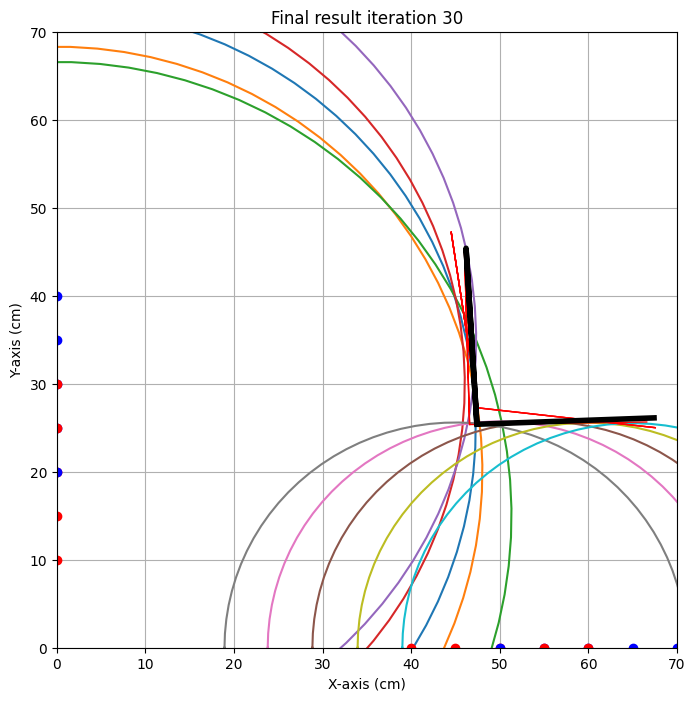

{'alpha': np.float64(2.073077952523108), 'alpha_eps': np.float64(8.491962810512351), 'beta': np.float64(-3.5086613699131153), 'beta_eps': np.float64(5.147474493486625), 'x0': np.float64(47.418571031287165), 'x0_eps': np.float64(0.825565322102058), 'y0': np.float64(25.394106263848265), 'y0_eps': np.float64(1.8617466275908185)}
test locatie 
x0 target is : 48.0. Gevonden waarde: 47.4 cm met een standaardafwijking van 0.8 cm 
y0 target is : 25.0. Gevonden waarde: 25.4 cm met een standaardafwijking van 1.9 cm 
alpha target is : -1.0. Gevonden waarde: 2.1 graden met een standaardafwijking van 8.5 graad 
beta target is : -10.0. Gevonden waarde: -3.5 graden met een standaardafwijking van 5.1 graad 



In [11]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 48 ,
                    'y0': 25 ,
                    'alpha' :-1 ,
                    'beta' : -10 
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[       
                                [0,20,0,30,95.11],
                                [0,15,0,25,96.6],
                                [0,10,0,20,103.14],
                                # [0,5,0,10,np.nan], 
                                [0,25,0,35,92.65],
                                [0,30,0,40,95.2],
                                # [0,35,0,45,]   
                                # [20,0,30,0,np.nan]
                                # [35,0,45,0]
                                [50,0,60,0,52.31],
                                [45,0,55,0,52.4],
                                [40,0,50,0,52.16],
                                [55,0,65,0,52.1]  ,
                                [60,0,70,0,52.0]  ,               

                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

we hebben met de locatie gegeven door de TA geitereerd. we hebben het eerste algoritme verandert naar het hieronder gegeven algoritme.


test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0   0  20   0  30   95.11
1   0  15   0  25   96.60
2   0  10   0  20  103.14
3   0  25   0  35   92.65
4   0  30   0  40   95.20
5  50   0  60   0   52.31
6  45   0  55   0   52.40
7  40   0  50   0   52.16
8  55   0  65   0   52.10
9  60   0  70   0   52.00


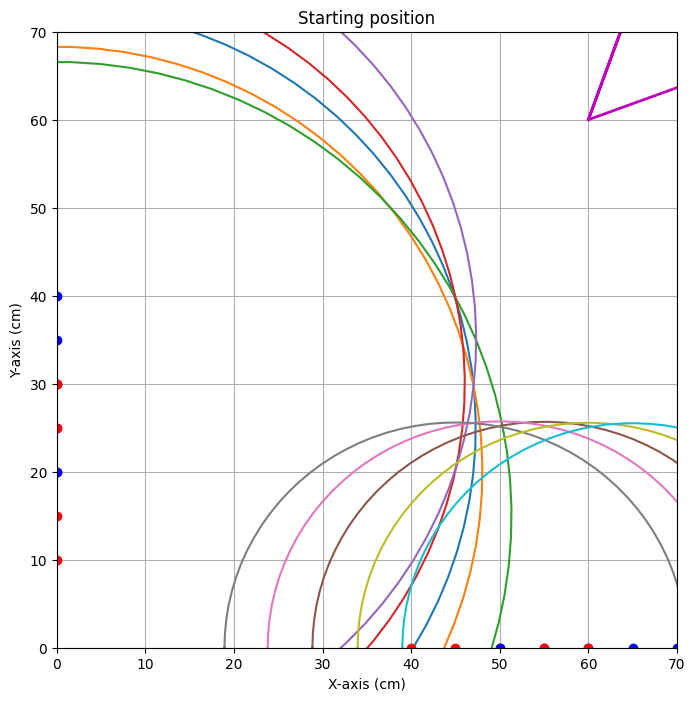


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=63.755


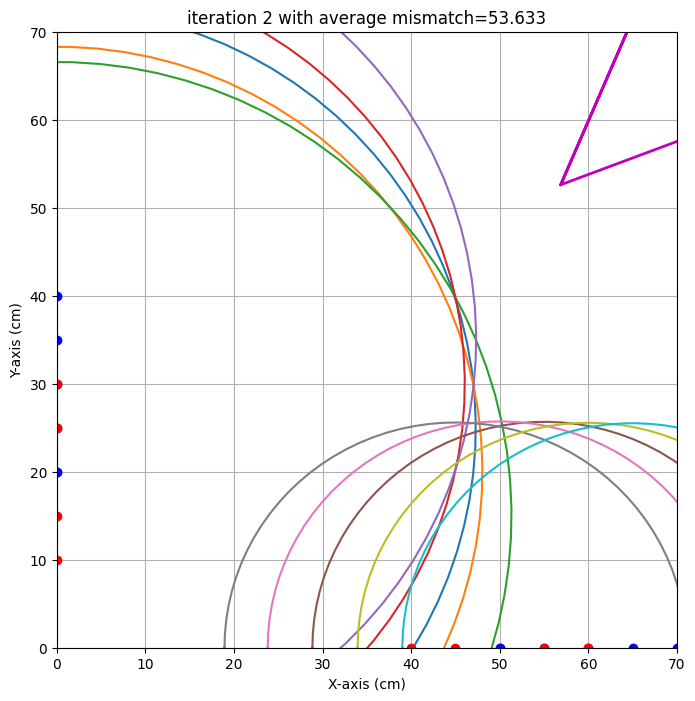

end iteration 2 with average mismatch=53.633


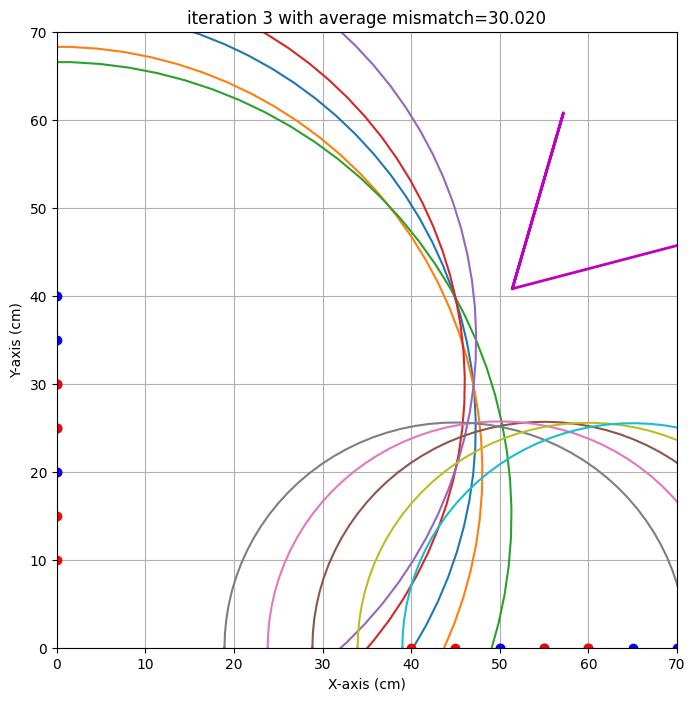

end iteration 3 with average mismatch=30.020


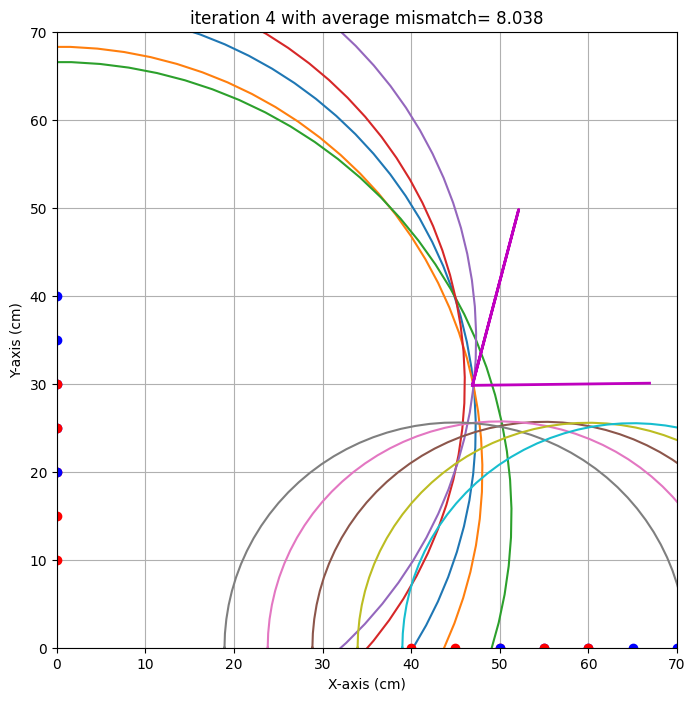

end iteration 4 with average mismatch= 8.038


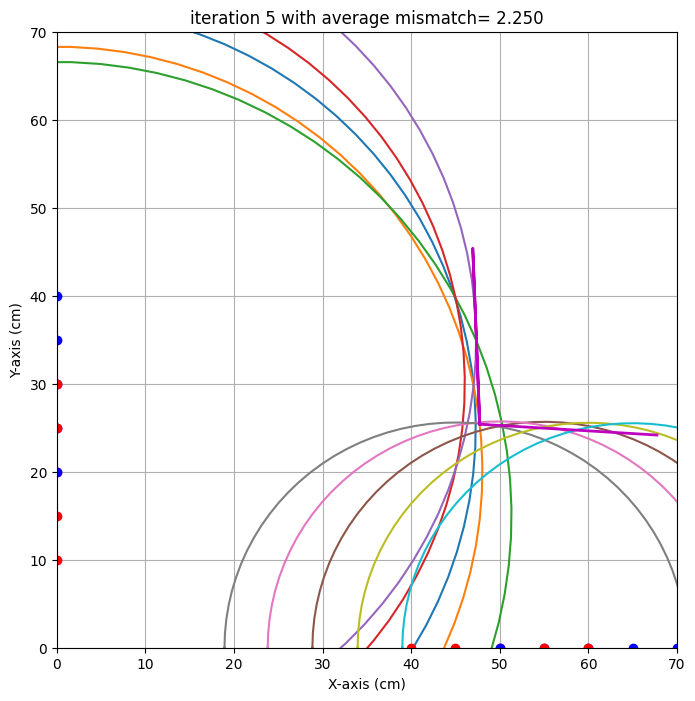

end iteration 5 with average mismatch= 2.250


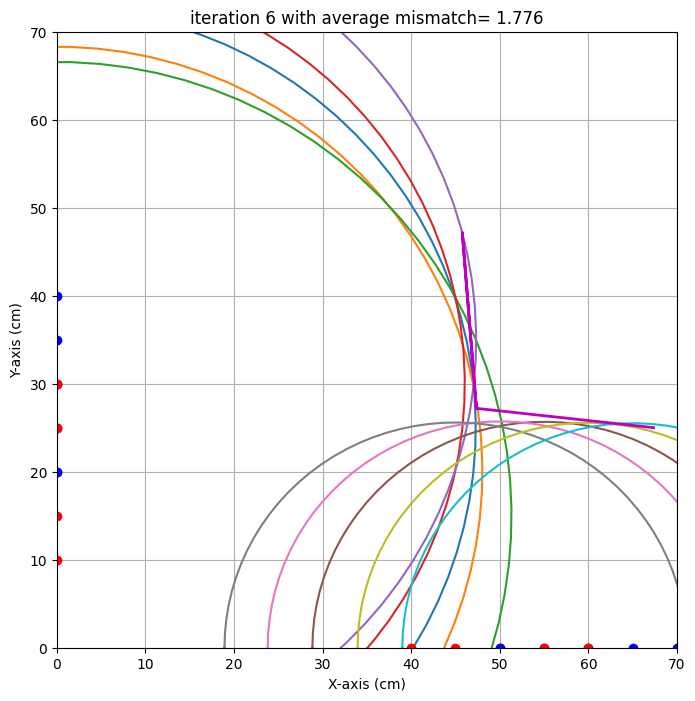

end iteration 6 with average mismatch= 1.776
end iteration 7 with average mismatch= 1.755
end iteration 8 with average mismatch= 1.755
end iteration 9 with average mismatch= 1.755
end iteration 10 with average mismatch= 1.755
end iteration 11 with average mismatch= 1.755
end iteration 12 with average mismatch= 1.755
end iteration 13 with average mismatch= 1.755
end iteration 14 with average mismatch= 1.755
end iteration 15 with average mismatch= 1.755
end iteration 16 with average mismatch= 1.755
end iteration 17 with average mismatch= 1.755
end iteration 18 with average mismatch= 1.755
end iteration 19 with average mismatch= 1.755
end iteration 20 with average mismatch= 1.755
end iteration 21 with average mismatch= 1.755
end iteration 22 with average mismatch= 1.755
end iteration 23 with average mismatch= 1.755
end iteration 24 with average mismatch= 1.755
end iteration 25 with average mismatch= 1.755
end iteration 26 with average mismatch= 1.721
end iteration 27 with average mismatch

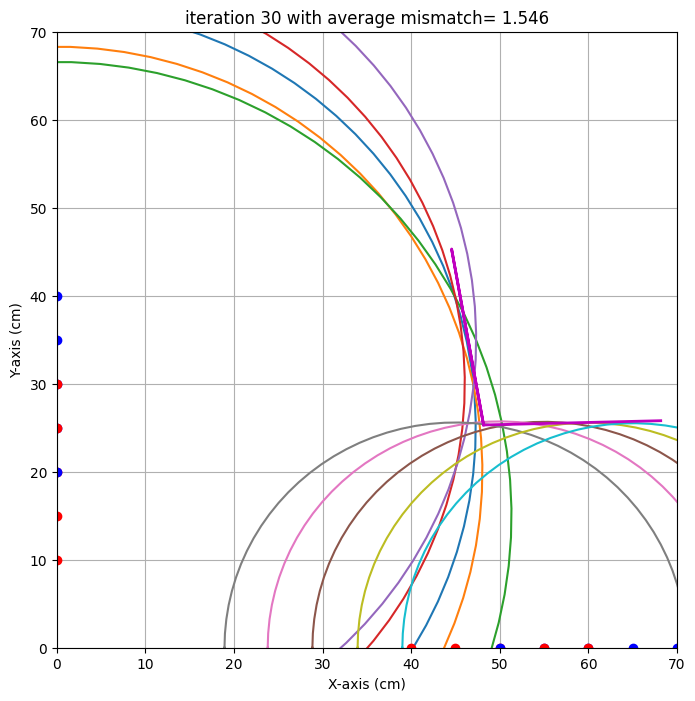

end iteration 30 with average mismatch= 1.546
###############################################################################
end of iteration  30
Best alpha=   1.39 with uncertainty=   3.46
Best beta = -10.24 with uncertainty=   9.68
Best x0   =  48.17 with uncertainty=   0.74
Best y0   =  25.31 with uncertainty=   0.15
###############################################################################


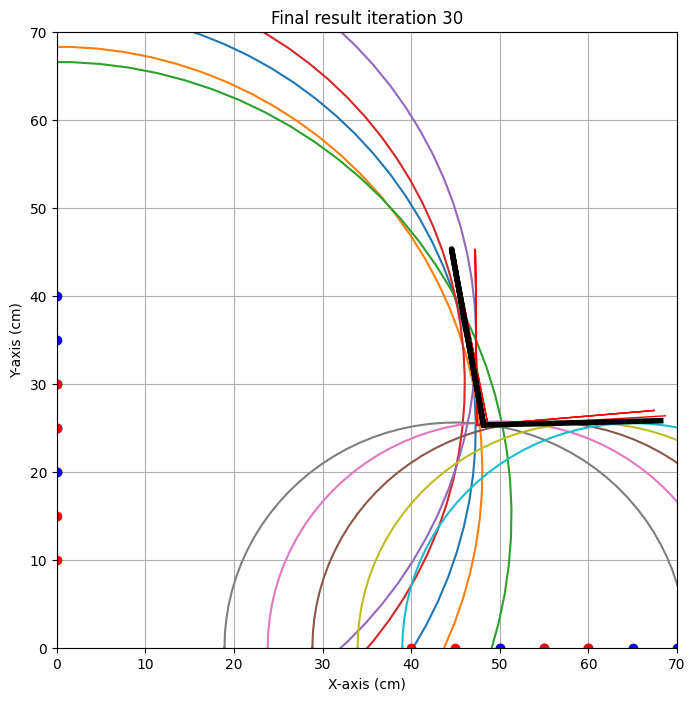

{'alpha': np.float64(1.3904187355702562), 'alpha_eps': np.float64(3.461054061744146), 'beta': np.float64(-10.241280146652706), 'beta_eps': np.float64(9.679167576521674), 'x0': np.float64(48.17308526445096), 'x0_eps': np.float64(0.7374814337918707), 'y0': np.float64(25.3122876461016), 'y0_eps': np.float64(0.14952451713348935)}
test locatie 
x0 target is : 48.0. Gevonden waarde: 48.2 cm met een standaardafwijking van 0.7 cm 
y0 target is : 25.0. Gevonden waarde: 25.3 cm met een standaardafwijking van 0.1 cm 
alpha target is : -1.0. Gevonden waarde: 1.4 graden met een standaardafwijking van 3.5 graad 
beta target is : -10.0. Gevonden waarde: -10.2 graden met een standaardafwijking van 9.7 graad 



: 

In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 48 ,
                    'y0': 25 ,
                    'alpha' :-1 ,
                    'beta' : -10 
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[       
                                [0,20,0,30,95.11],
                                [0,15,0,25,96.6],
                                [0,10,0,20,103.14],
                                # [0,5,0,10,np.nan], 
                                [0,25,0,35,92.65],
                                [0,30,0,40,95.2],
                                # [0,35,0,45,]   
                                # [20,0,30,0,np.nan]
                                # [35,0,45,0]
                                [50,0,60,0,52.31],
                                [45,0,55,0,52.4],
                                [40,0,50,0,52.16],
                                [55,0,65,0,52.1]  ,
                                [60,0,70,0,52.0]  ,               

                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))